In [1]:
# Standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from scipy.stats import ttest_ind

# Own
from glue_sessions.glue_sessions import *
from intersession import glue_animals_intersessions
from my_fun import *
from licks.licks import *
from psychometric_curves import *
from kernels.psychophysical_kernels import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [8]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

# Analyses of drug data from batch #6

In [4]:
# Set parameters
experiment = '2AFC_6'  # Set the experiment (batch)
animals = ['014', '016', '017', '020', '021', '022', '023', '024', '025']

In [5]:
# Load intersession data
df_intersessions = glue_animals_intersessions(experiment=experiment, filter_drug=True, update=False, to_csv=False)

glue_animals_intersessions took 0.16 seconds to run


## Behavioral metrics

In [21]:
# Define function to compare behavioral metrics between saline and drug conditions

def plot_var_drug(df_intersessions, var_name='Accuracy'):
    """
    Plot a variable (e.g., accuracy) for each subject and drug condition together with the mean and sem across subjects, and run a t-test between saline and drug conditions.
    :param df_intersessions: DataFrame containing intersession data from all animals
    :param var_name: Name of the variable to plot (e.g., 'Accuracy')
    :return: None
    """

    var = df_intersessions.groupby(['Subject', 'Drug'])[var_name].mean().reset_index()
    var_mean = var.groupby('Drug')[var_name].mean()
    var_sem = var.groupby('Drug')[var_name].sem()

    # Plot paired lines
    # plt.figure(constrained_layout=True)
    default_fig_size = np.array(plt.rcParams['figure.figsize'])
    plt.figure(figsize=default_fig_size/2, constrained_layout=True)
    sns.lineplot(data=var, x='Drug', y=var_name, hue='Subject', marker='o', palette=['gray'] * var.Subject.nunique(), alpha=0.25, legend=False)
    # Plot mean and SEM
    plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color='k')
    # plt.title(var_name)
    plt.ylabel(var_name)
    # plt.ylim([0.5, 1])
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    # Run t-test
    saline = var[var['Drug'] == 0][var_name]
    drug = var[var['Drug'] == 1][var_name]
    t_stat, p_val = ttest_ind(saline, drug)
    print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
    add_star_between(p_val)

Accuracy: t-statistic = 3.049, p-value = 0.008
AccMaxEvi: t-statistic = 3.333, p-value = 0.004
LateralBias: t-statistic = -0.441, p-value = 0.665
AbsLatBias: t-statistic = -2.308, p-value = 0.035
MissRate: t-statistic = 0.391, p-value = 0.701
CorrRepBias: t-statistic = -3.939, p-value = 0.001


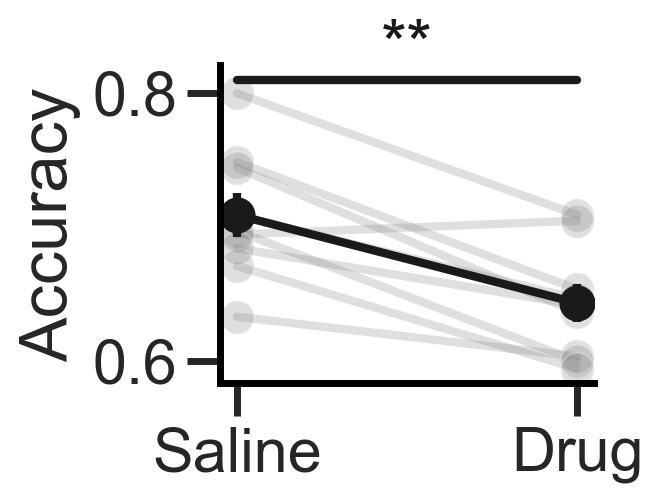

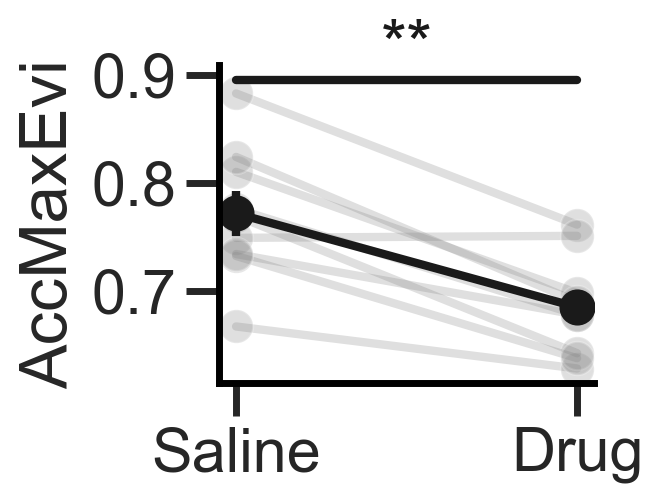

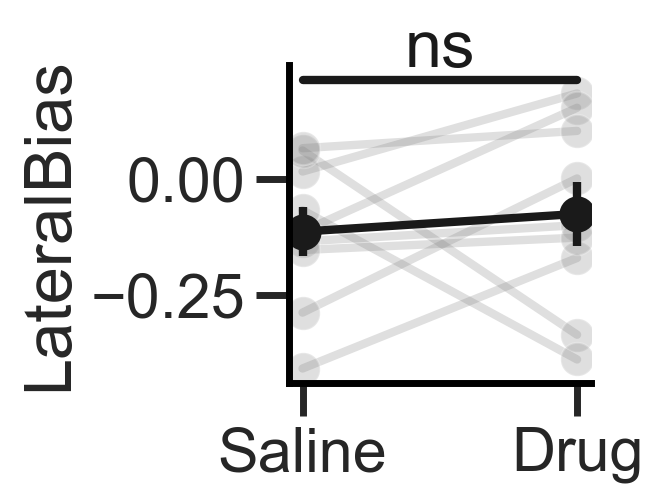

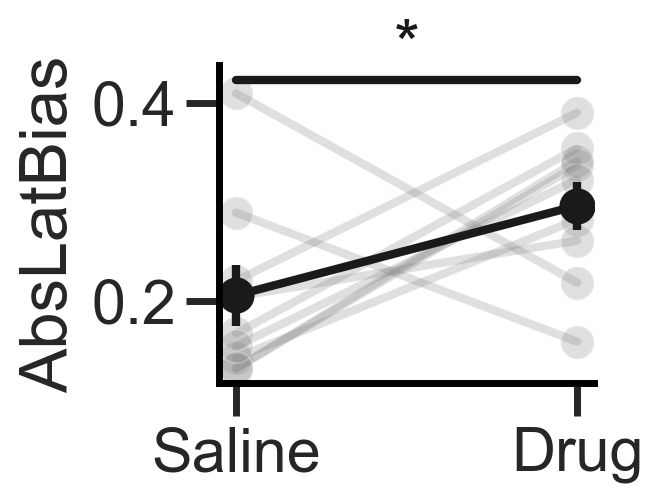

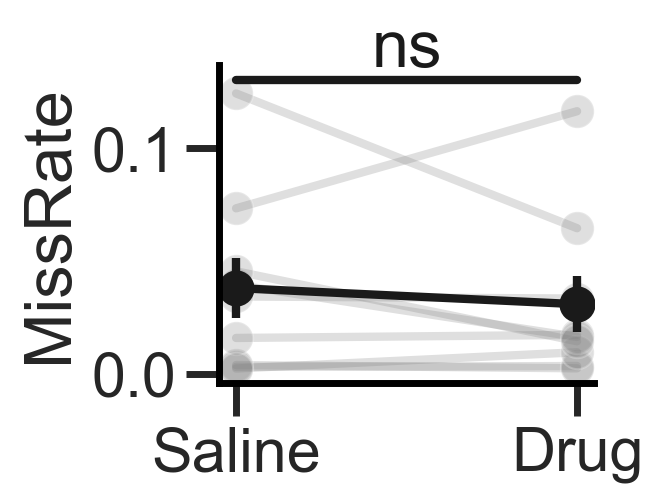

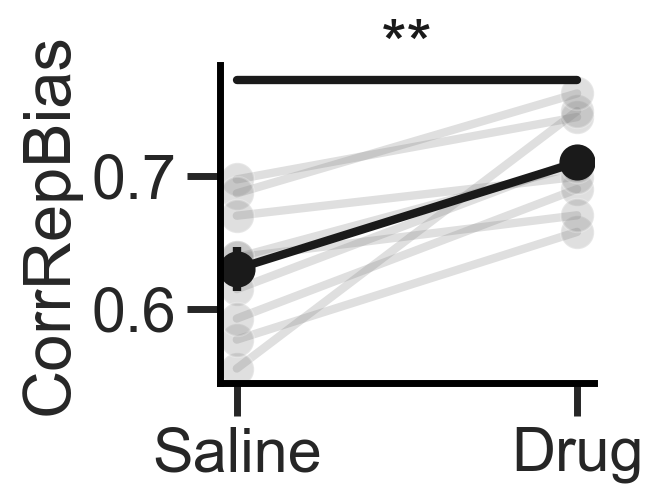

In [22]:
df_intersessions['AbsLatBias'] = abs(df_intersessions.LateralBias)  # Add new column

plot_var_drug(df_intersessions, var_name='Accuracy')
plot_var_drug(df_intersessions, var_name='AccMaxEvi')
plot_var_drug(df_intersessions, var_name='LateralBias')
plot_var_drug(df_intersessions, var_name='AbsLatBias')
plot_var_drug(df_intersessions, var_name='MissRate')
plot_var_drug(df_intersessions, var_name='CorrRepBias')

## Psychometrics

In [8]:
def compare_psych_params(params, param_name):
    """
    Compare the parameters of the saline and drug conditions.
    """

    # Plot seaborn boxplot comparing parameters
    # plt.figure(constrained_layout=True)
    default_fig_size = np.array(plt.rcParams['figure.figsize'])
    plt.figure(figsize=default_fig_size/2, constrained_layout=True)
    sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], linewidth=2.5, showfliers=False, legend=False)
    # sns.swarmplot(data=params, x='drug', y=param_name, color='k', legend=False)
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]

    t_stat, p_val = ttest_ind(saline, drug)
    print(f"{param_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

    add_star_between(p_val)

### Probability choose RIGHT

In [9]:
kind= 'prob_right'

#### Single animals

Animal 014
plot_pc took 1.22 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.28 seconds to run
plot_pc_drug took 2.53 seconds to run
Animal 016
plot_pc took 1.52 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.40 seconds to run
plot_pc_drug took 2.94 seconds to run
Animal 017
plot_pc took 1.49 seconds to run


...

plot_pc took 1.15 seconds to run
plot_pc_drug took 2.24 seconds to run
Animal 024
plot_pc took 1.04 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.14 seconds to run
plot_pc_drug took 2.20 seconds to run
Animal 025
plot_pc took 1.18 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.12 seconds to run
plot_pc_drug took 2.32 seconds to run


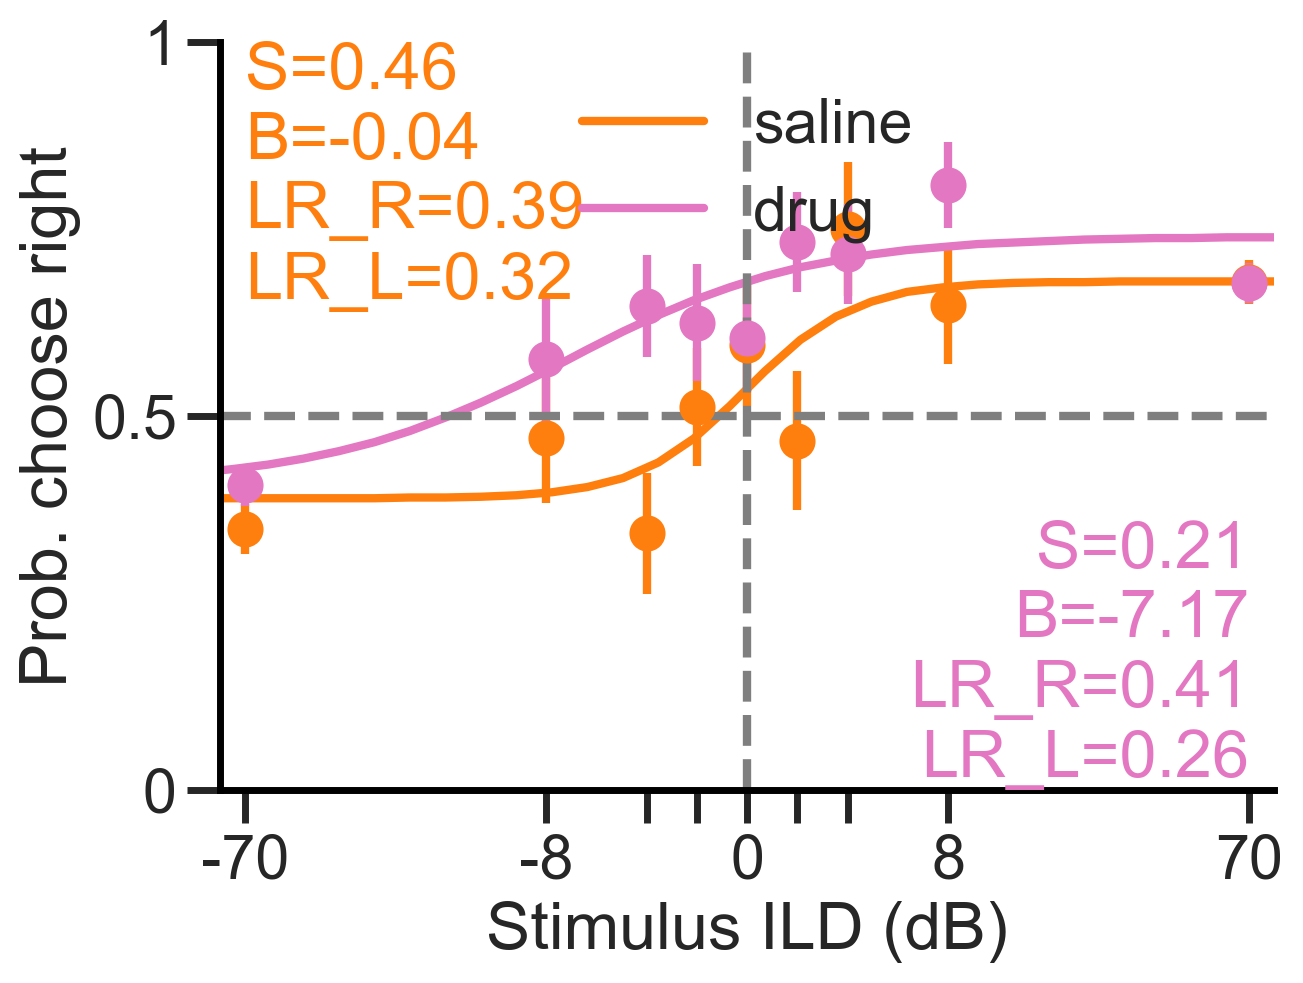

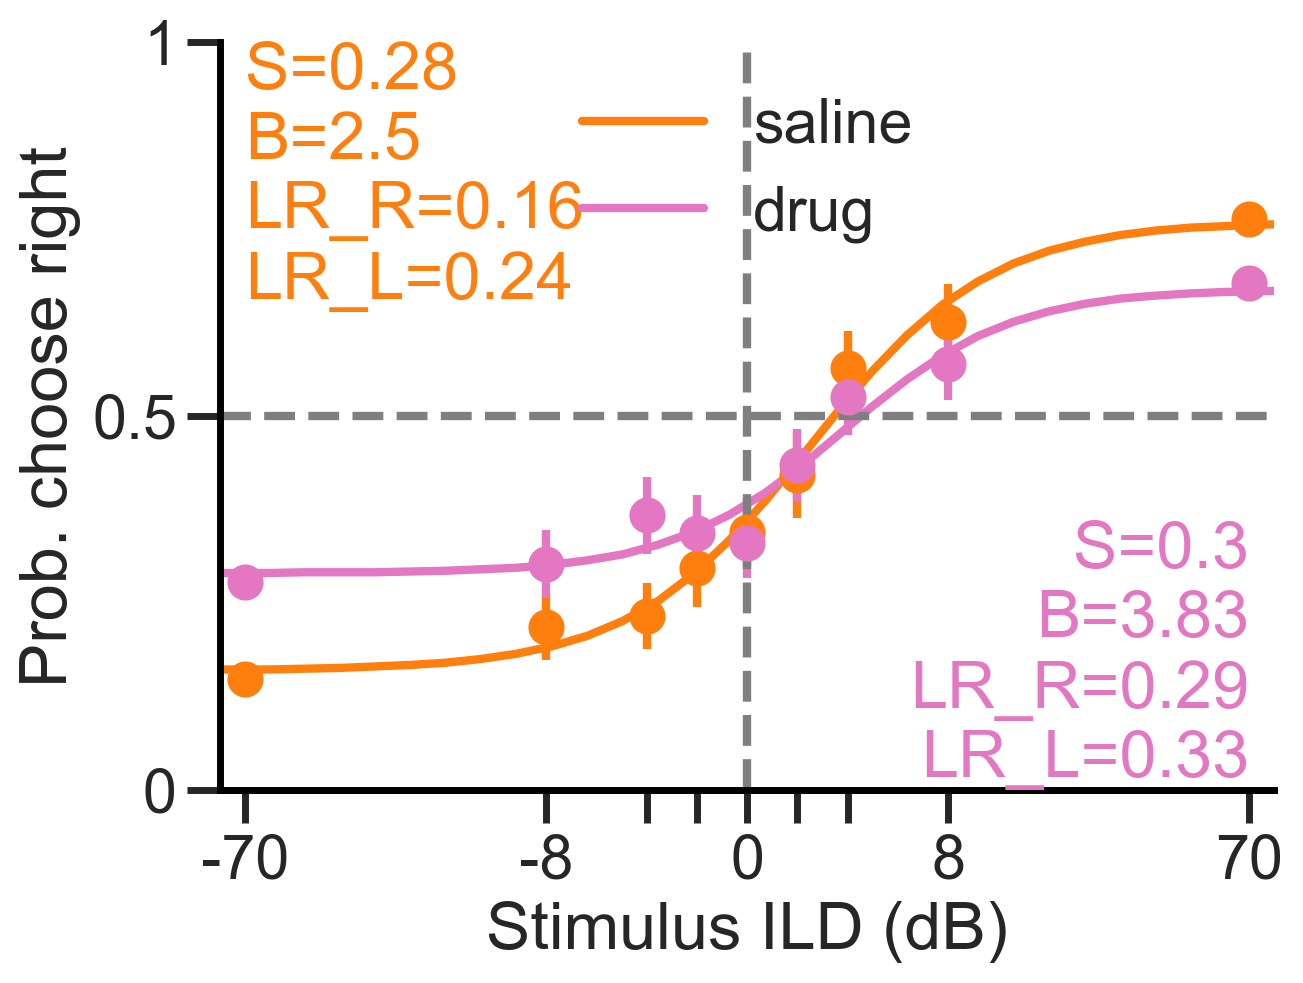

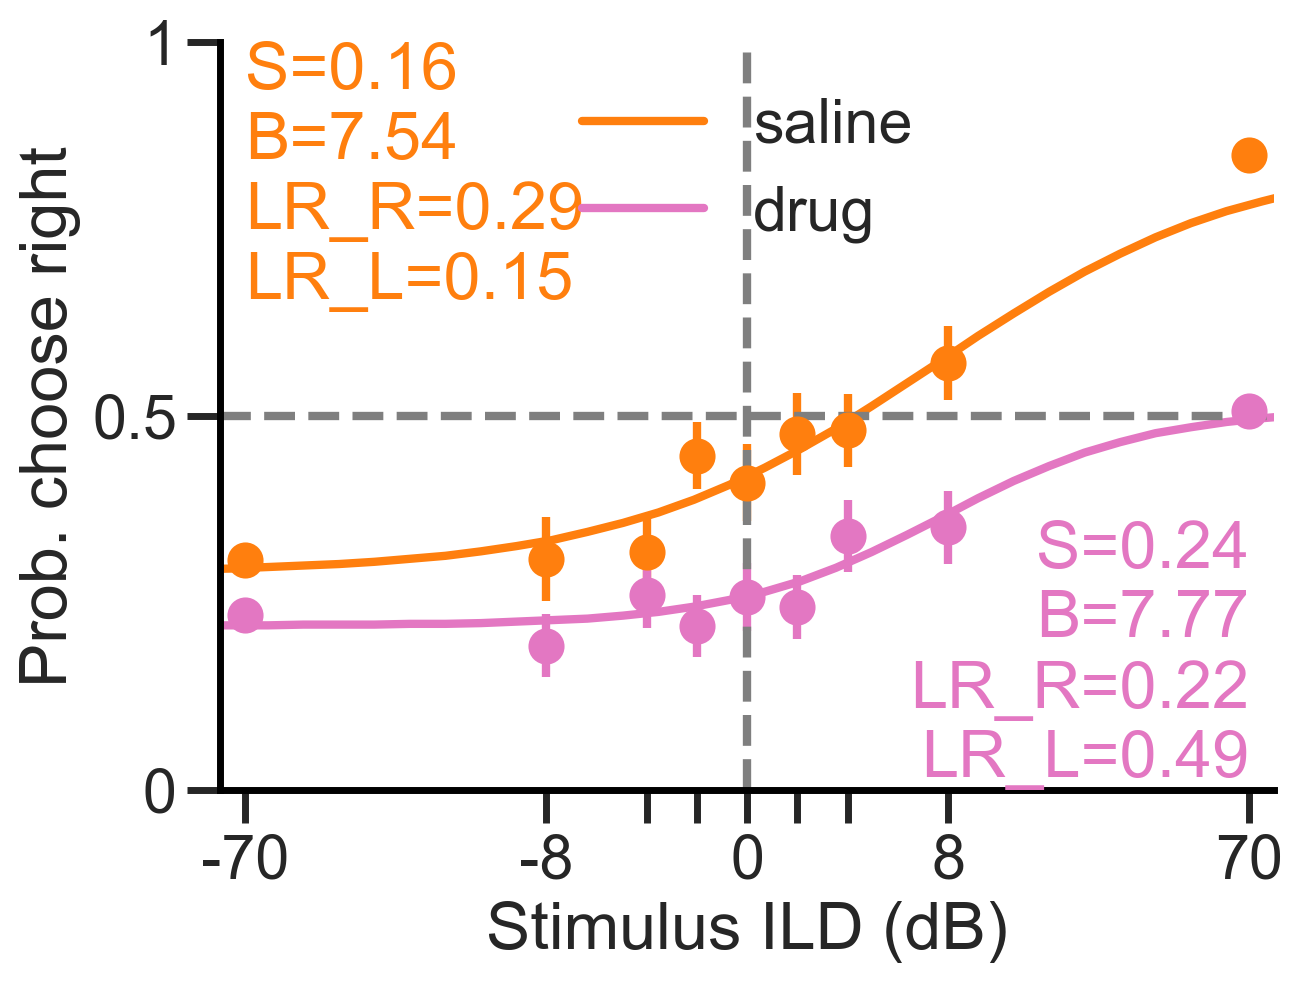

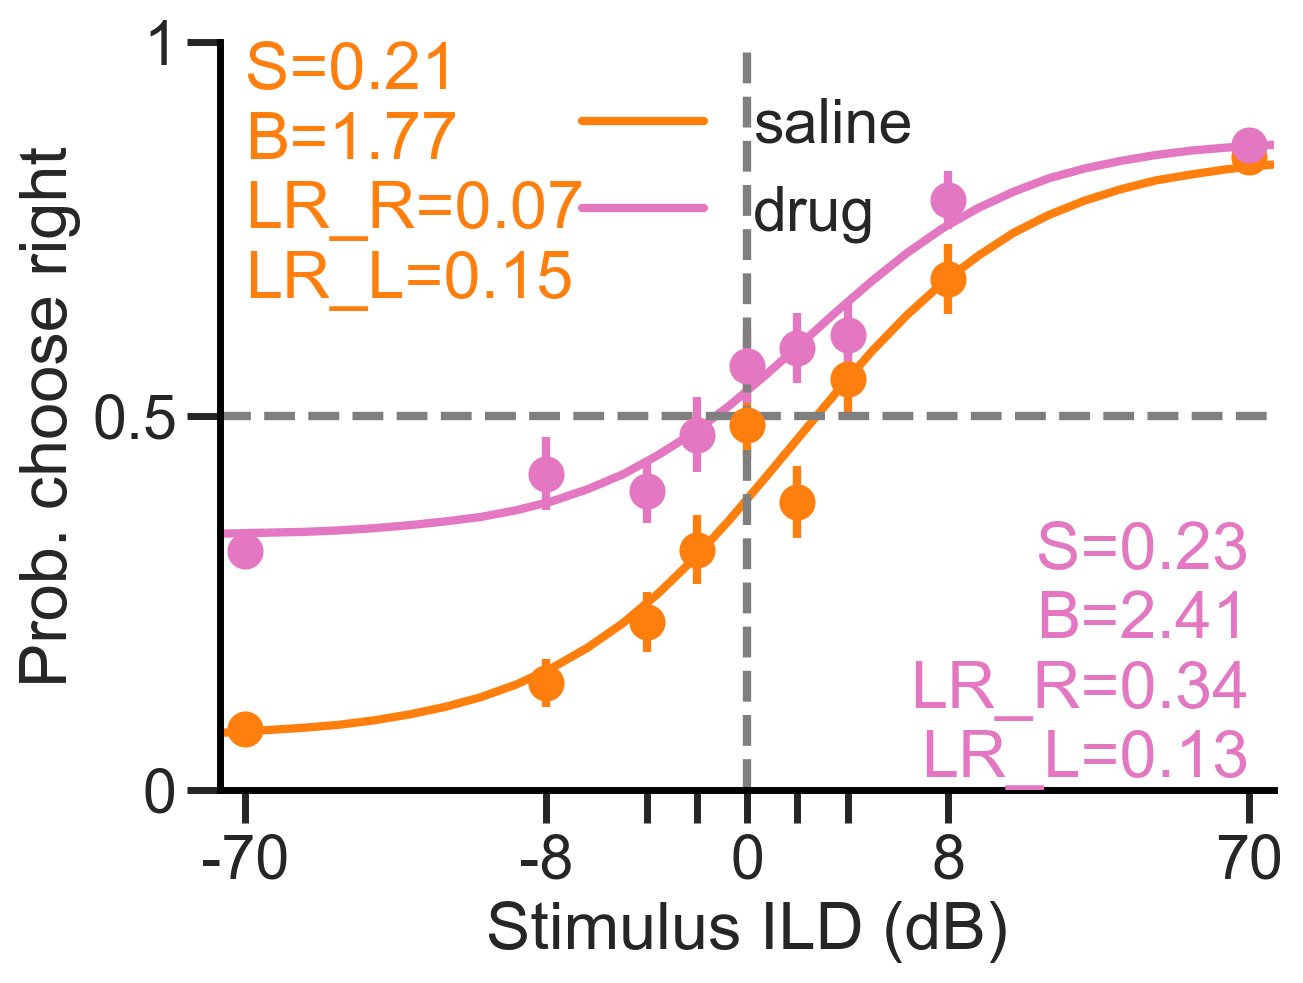

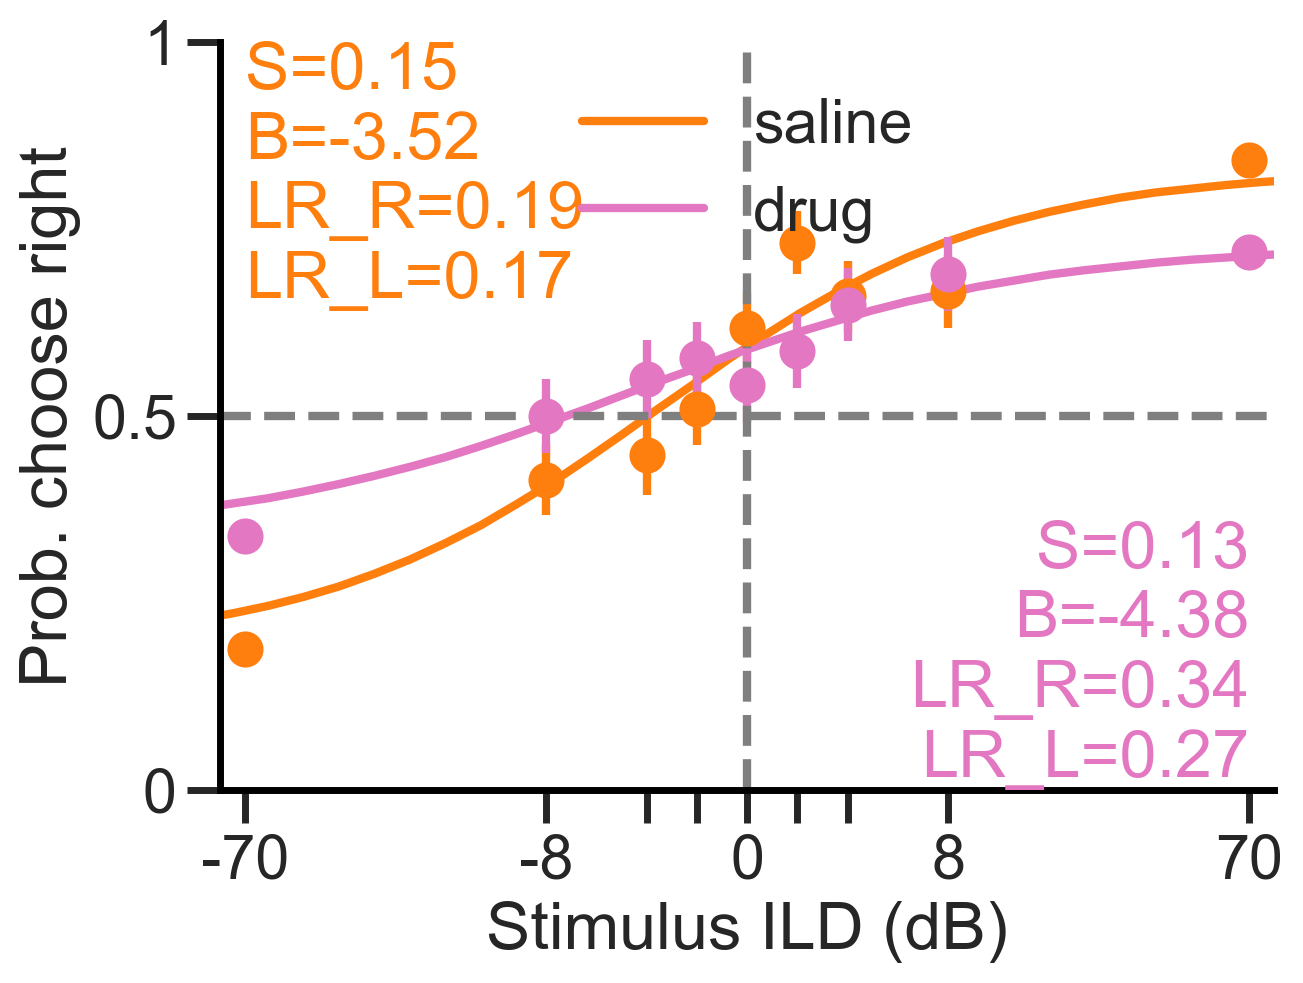

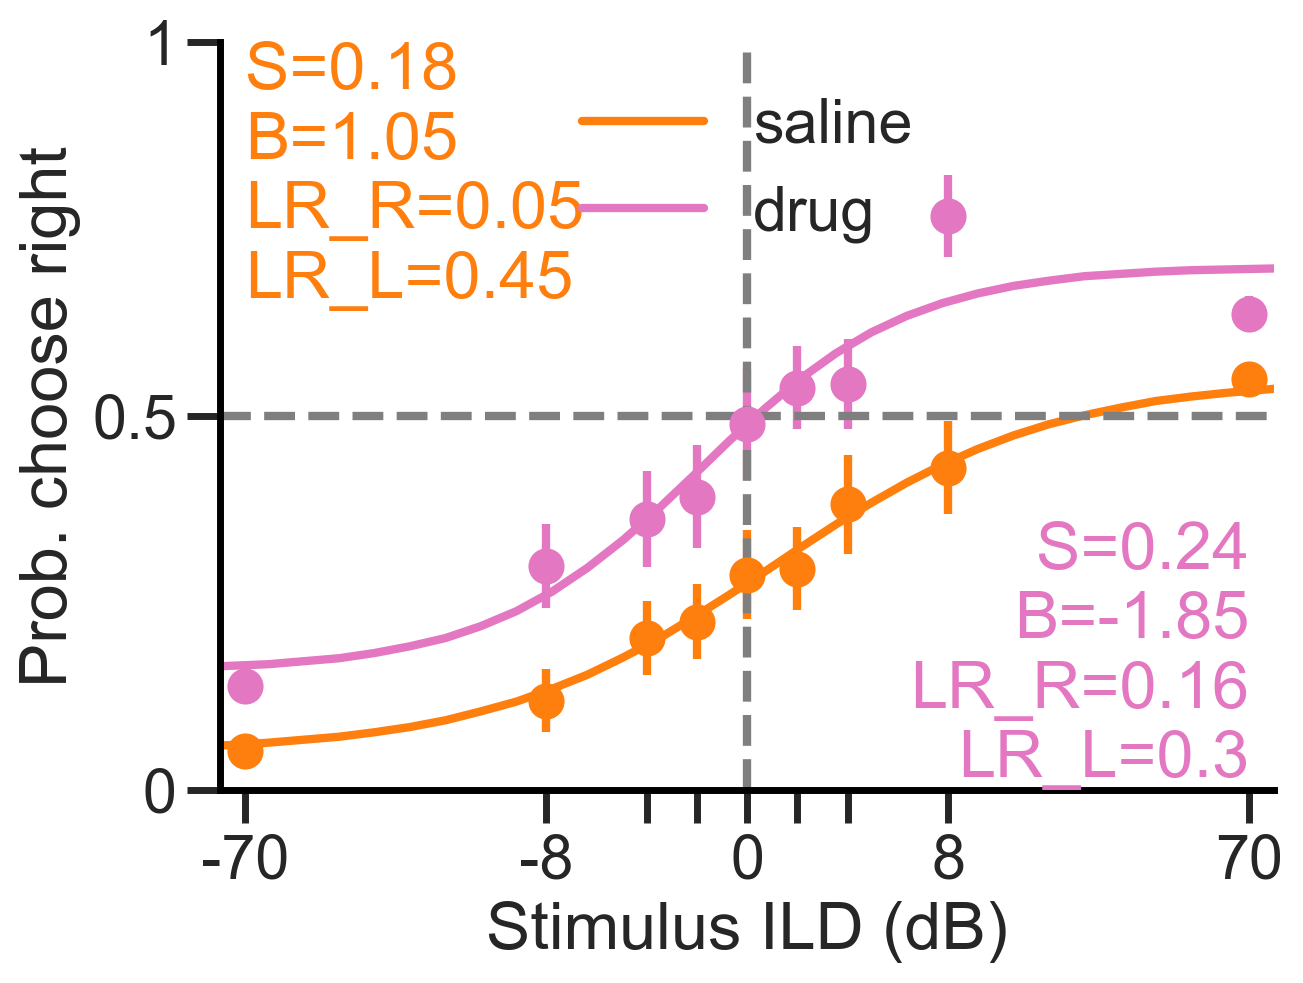

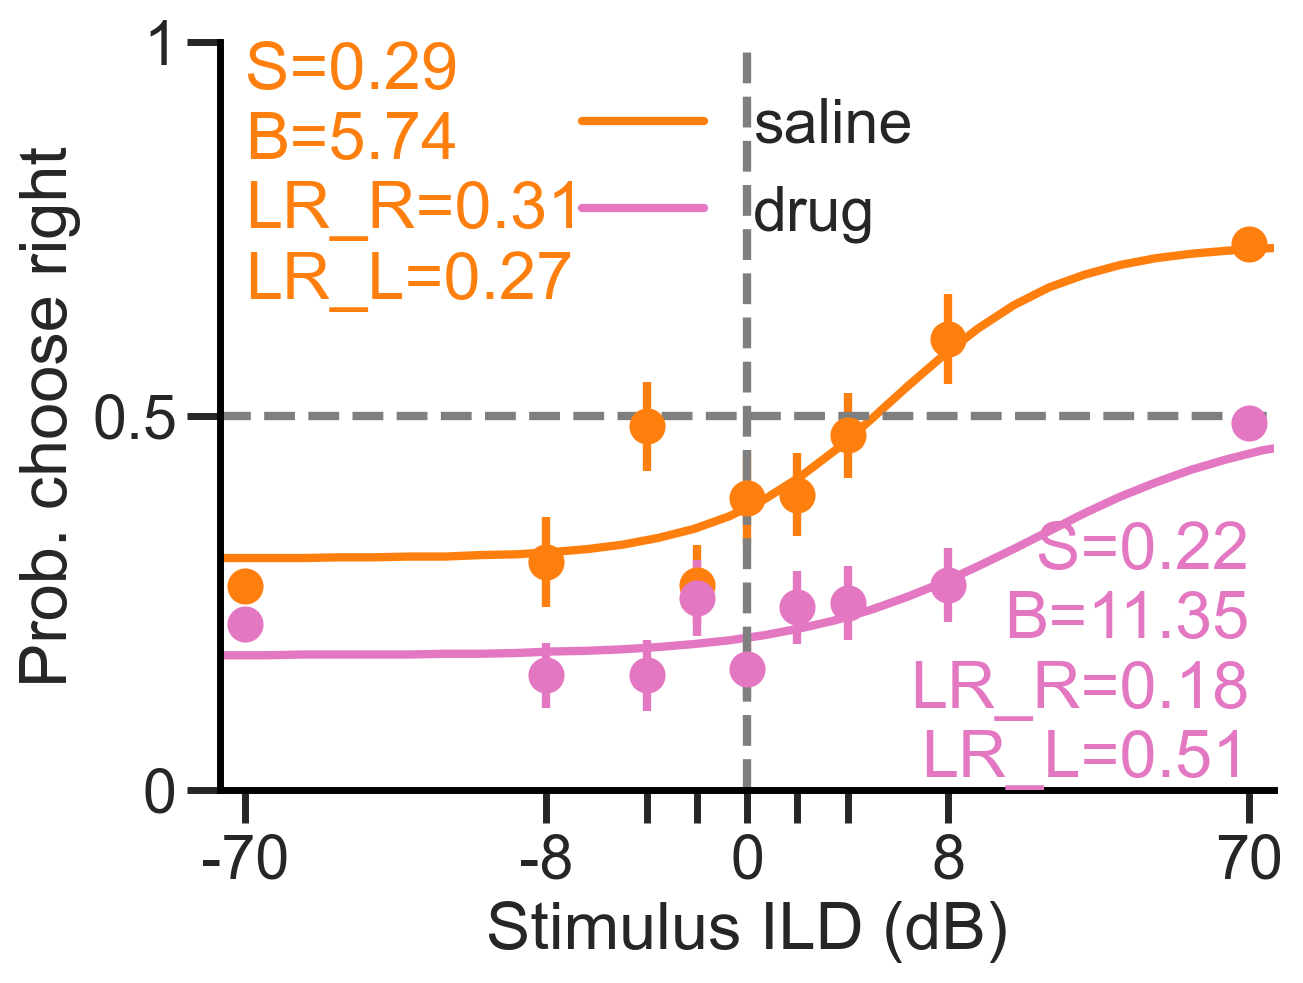

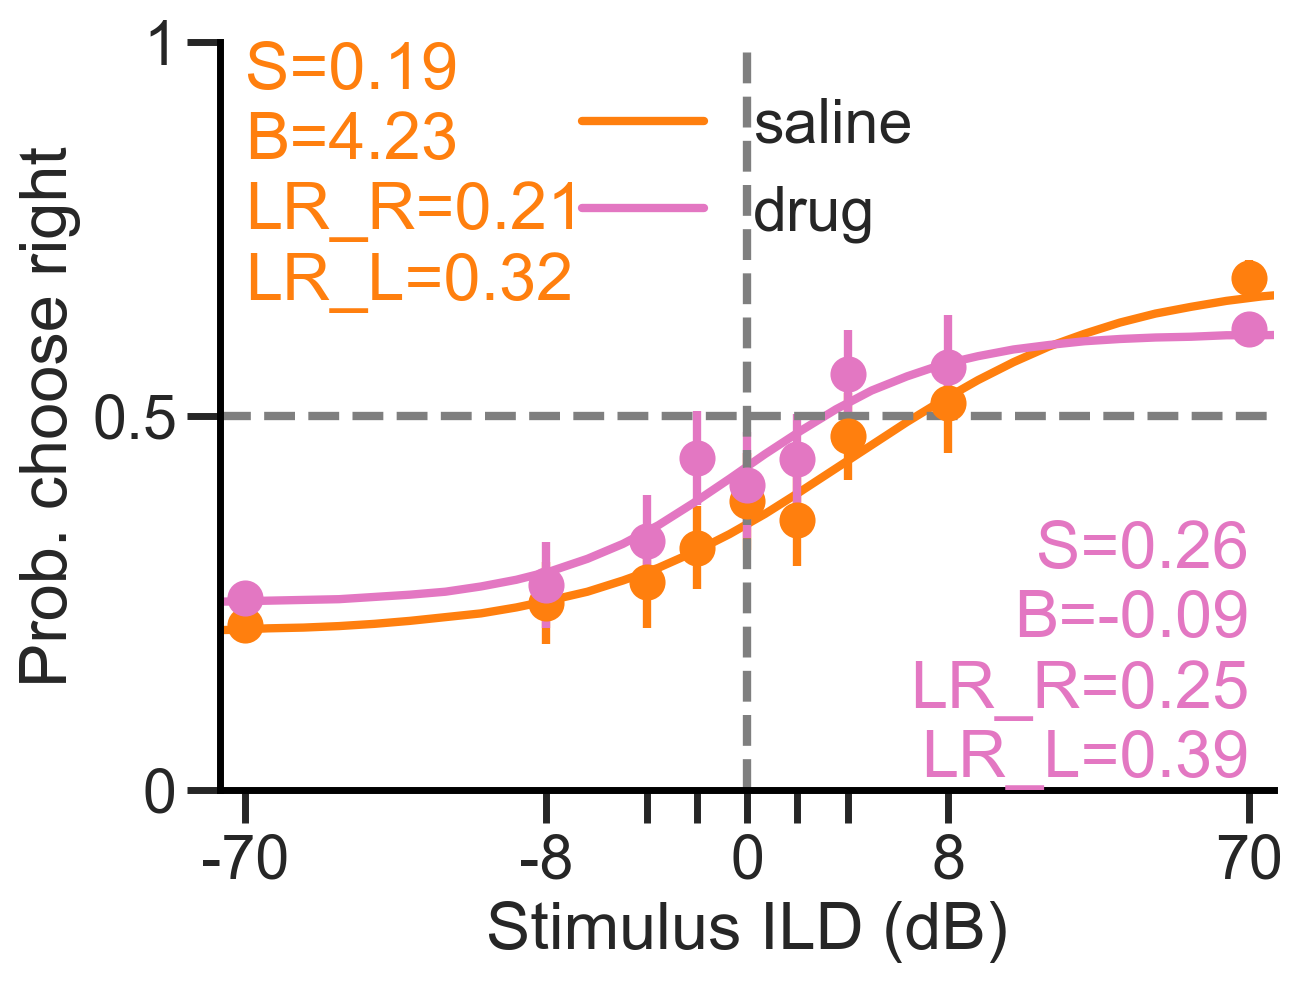

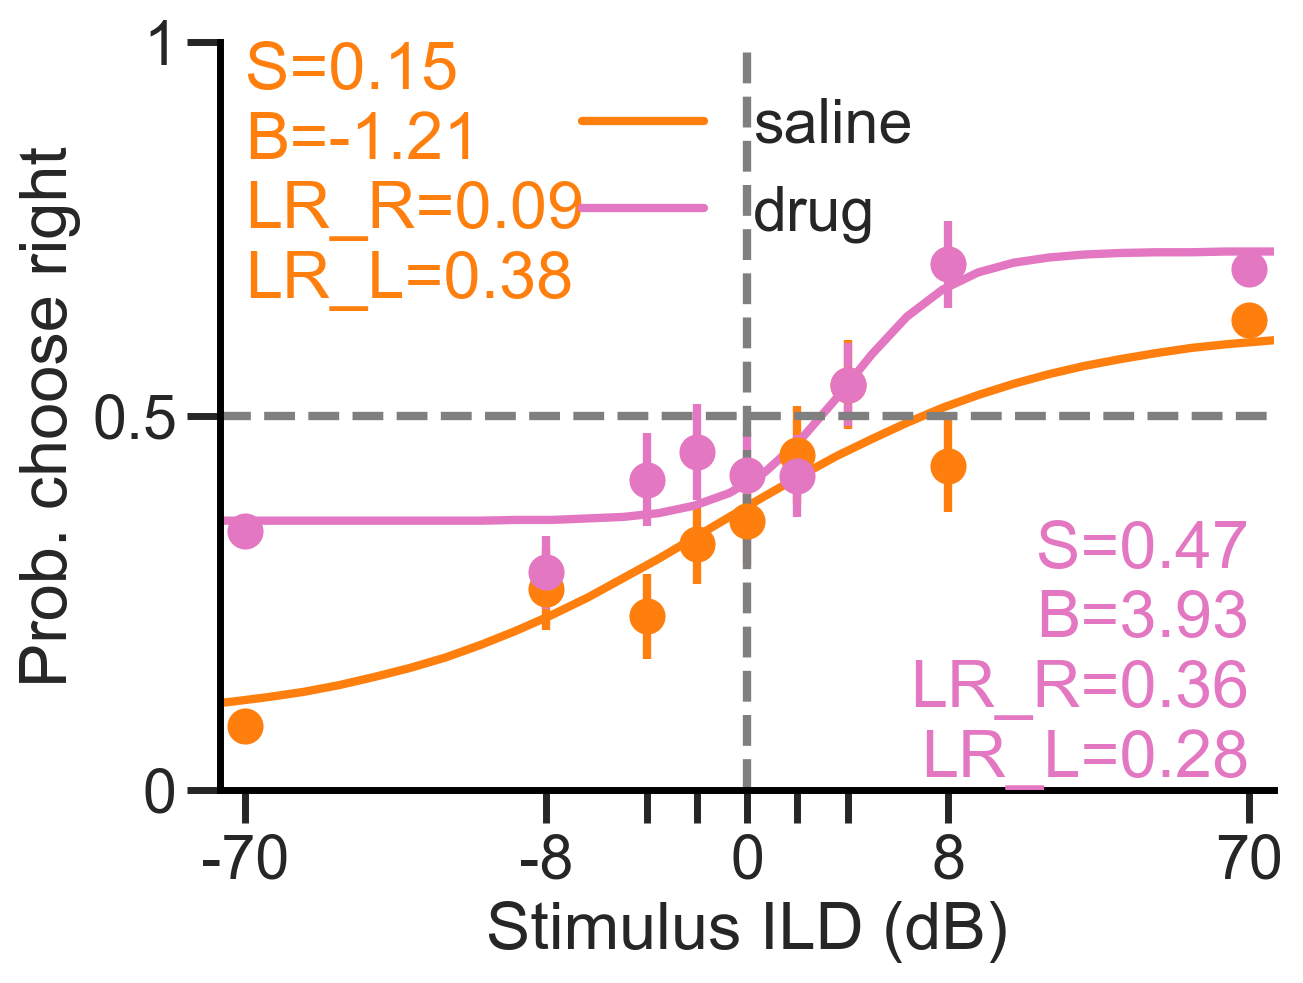

In [10]:
for animal in animals:
    print(f'Animal {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)


#### Mean across animals

plot_mean_pc took 11.13 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:488: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 11.09 seconds to run
plot_mean_pc_drug took 22.24 seconds to run


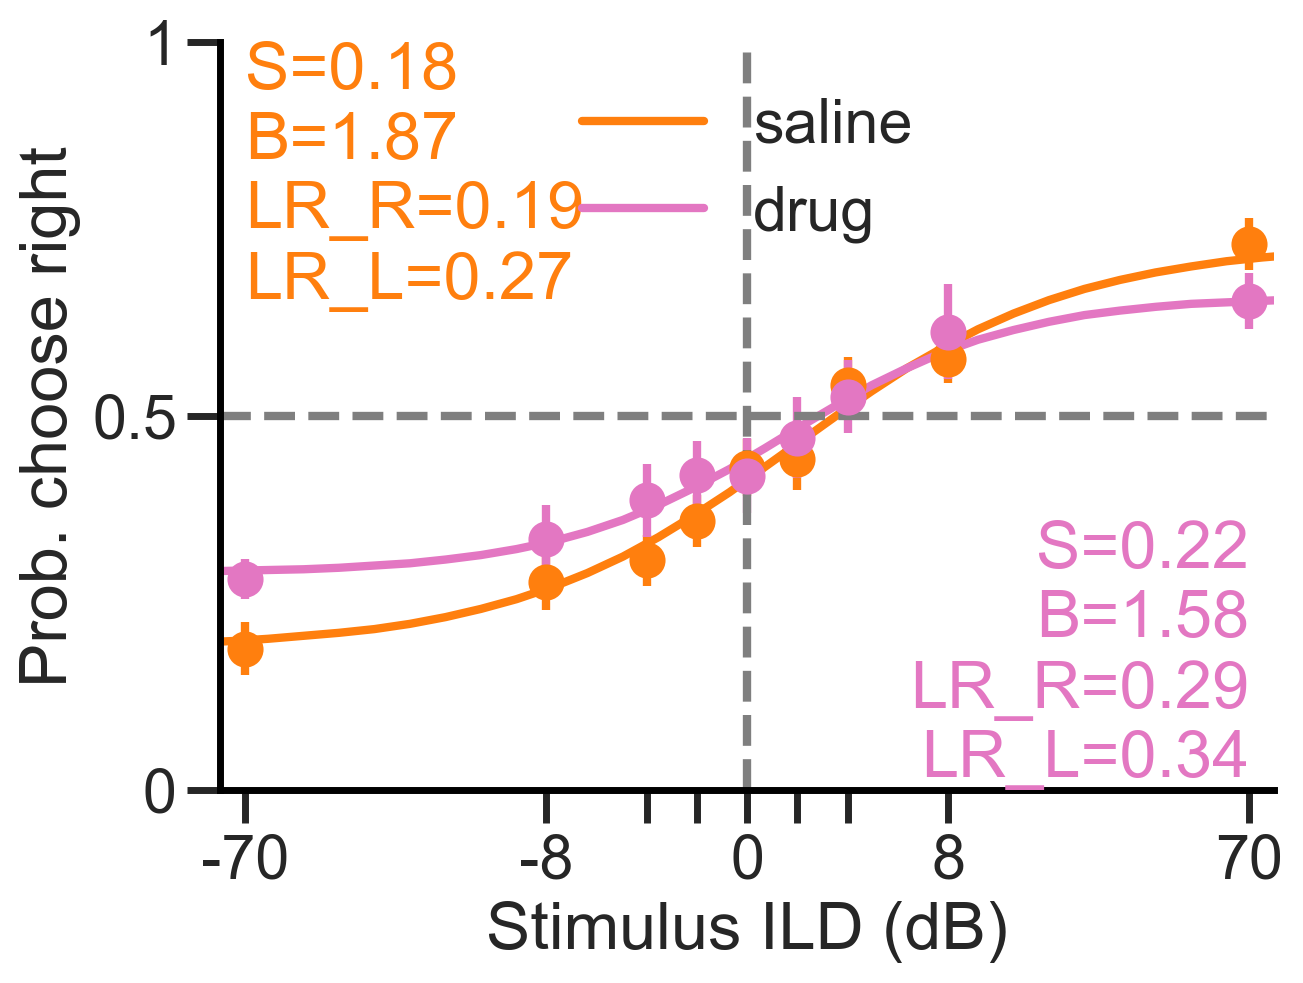

In [11]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

##### Stats

sensitivity: t-statistic = -0.561, p-value = 0.583
bias: t-statistic = 0.111, p-value = 0.913
lr_right: t-statistic = -1.813, p-value = 0.089
lr_left: t-statistic = -1.068, p-value = 0.301


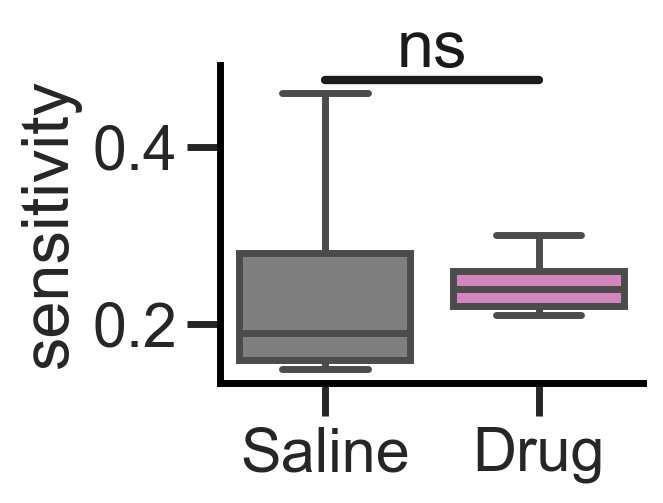

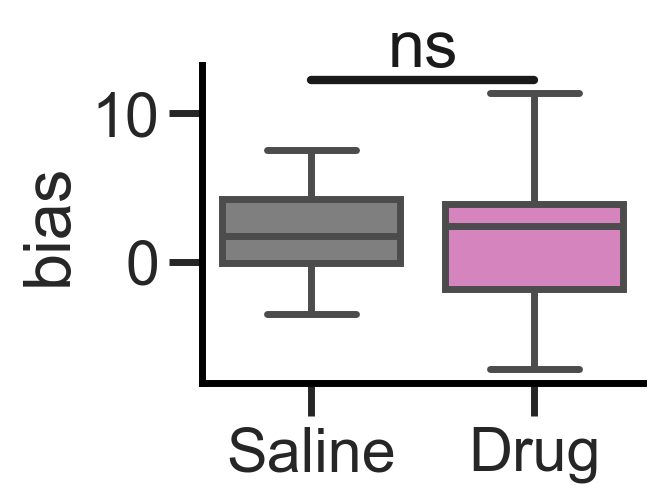

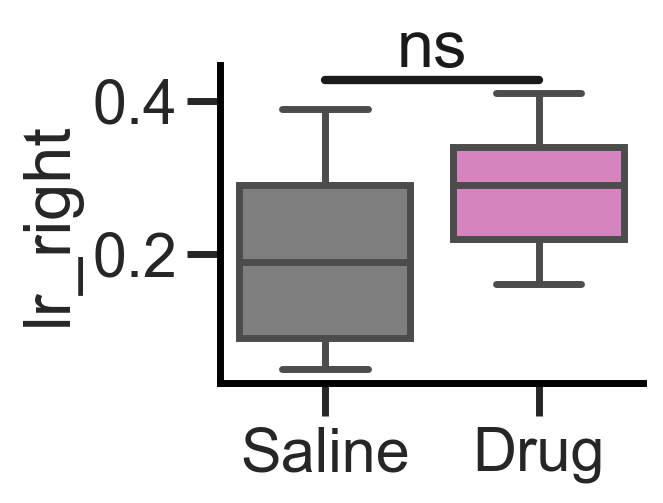

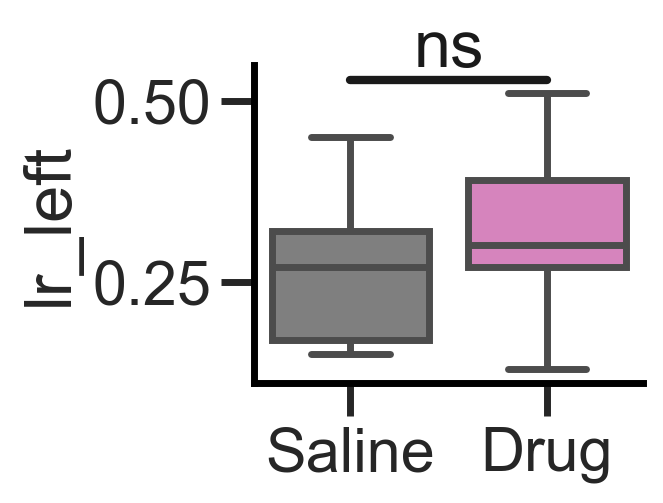

In [12]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_right')
compare_psych_params(params, 'lr_left')

### Probability choose REPAT

In [13]:
kind = 'prob_rep'

#### Single animals

Animal 014
plot_pc took 1.34 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.25 seconds to run
plot_pc_drug took 2.60 seconds to run
Animal 016
plot_pc took 1.36 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.35 seconds to run
plot_pc_drug took 2.73 seconds to run
Animal 017
plot_pc took 1.57 seconds to run


...

plot_pc took 1.07 seconds to run
plot_pc_drug took 2.16 seconds to run
Animal 024
plot_pc took 1.16 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.03 seconds to run
plot_pc_drug took 2.21 seconds to run
Animal 025
plot_pc took 1.03 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.06 seconds to run
plot_pc_drug took 2.12 seconds to run


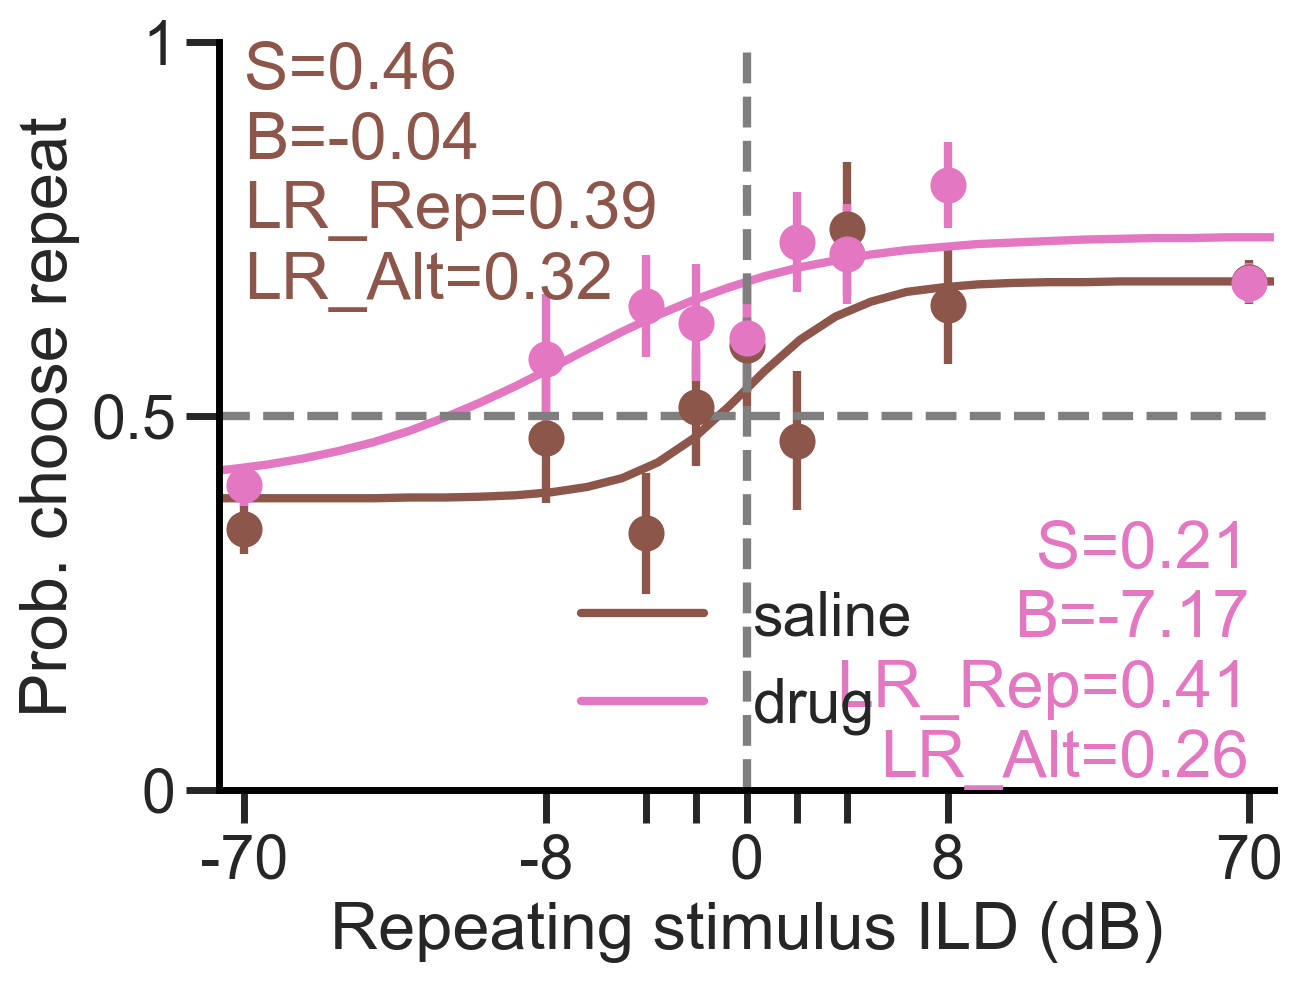

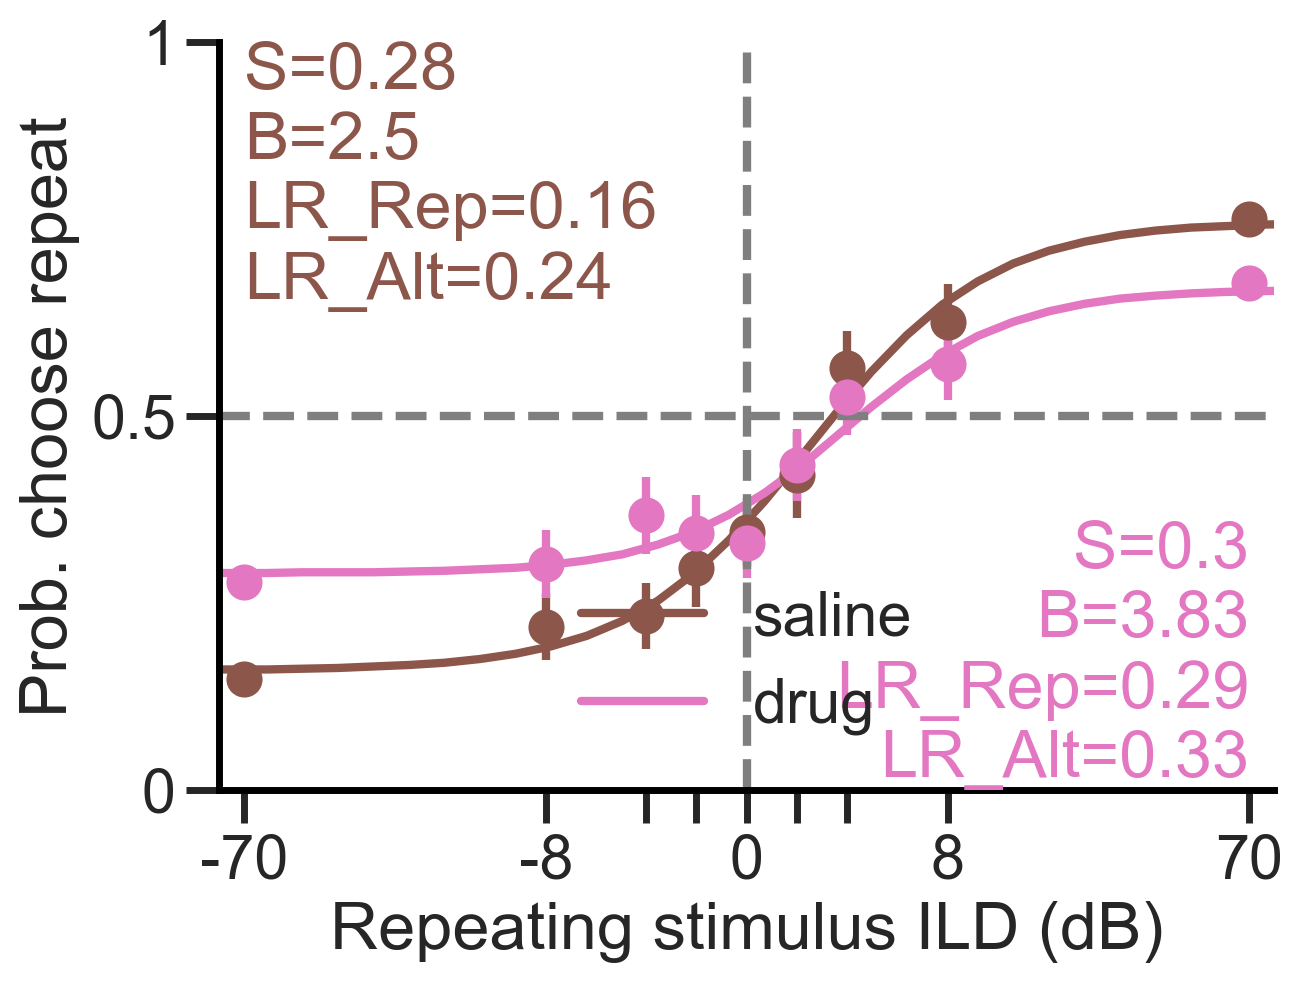

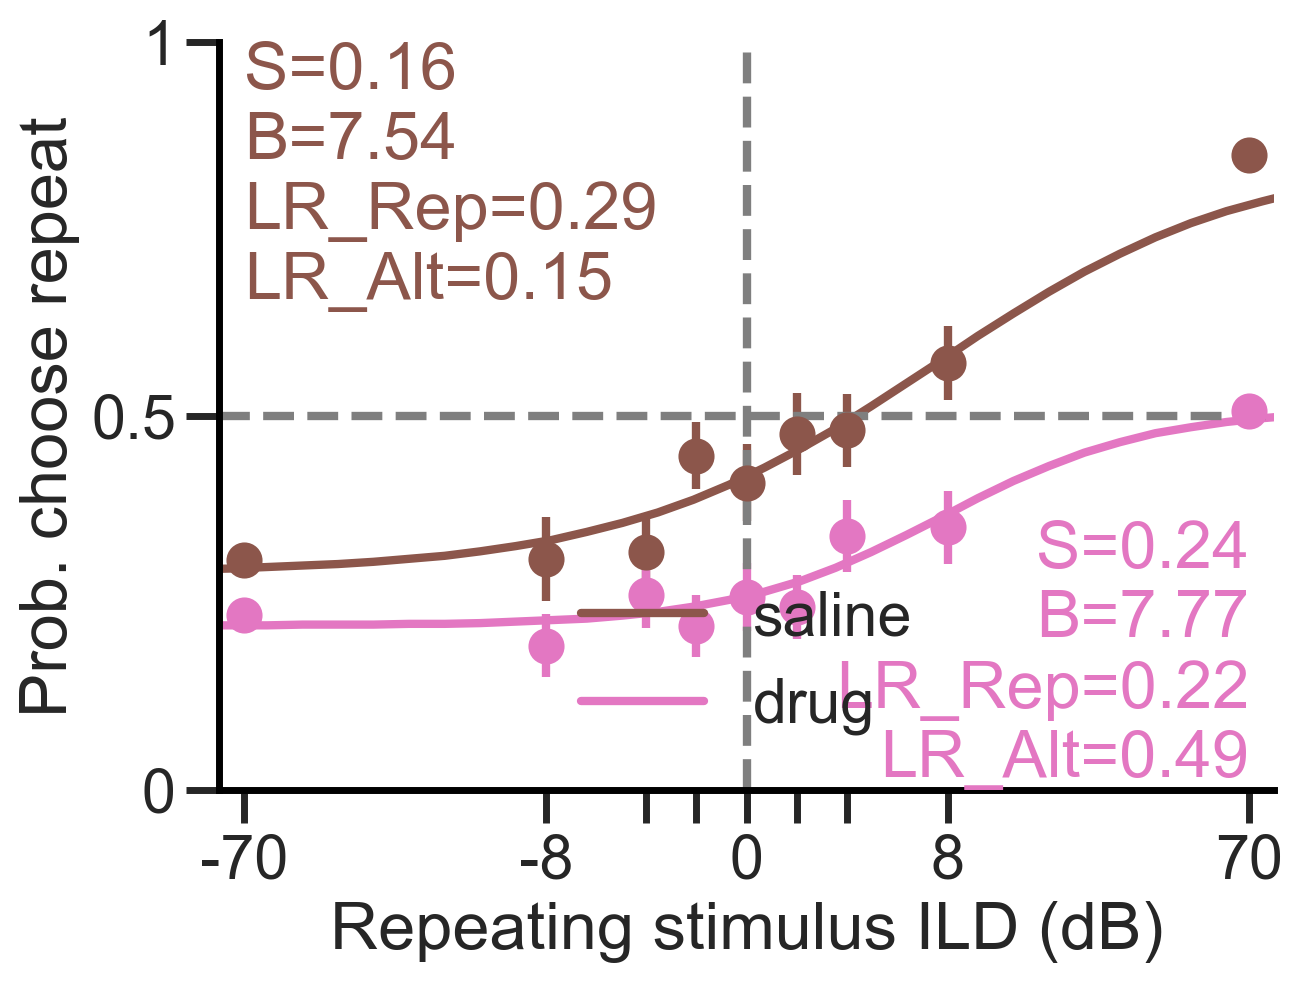

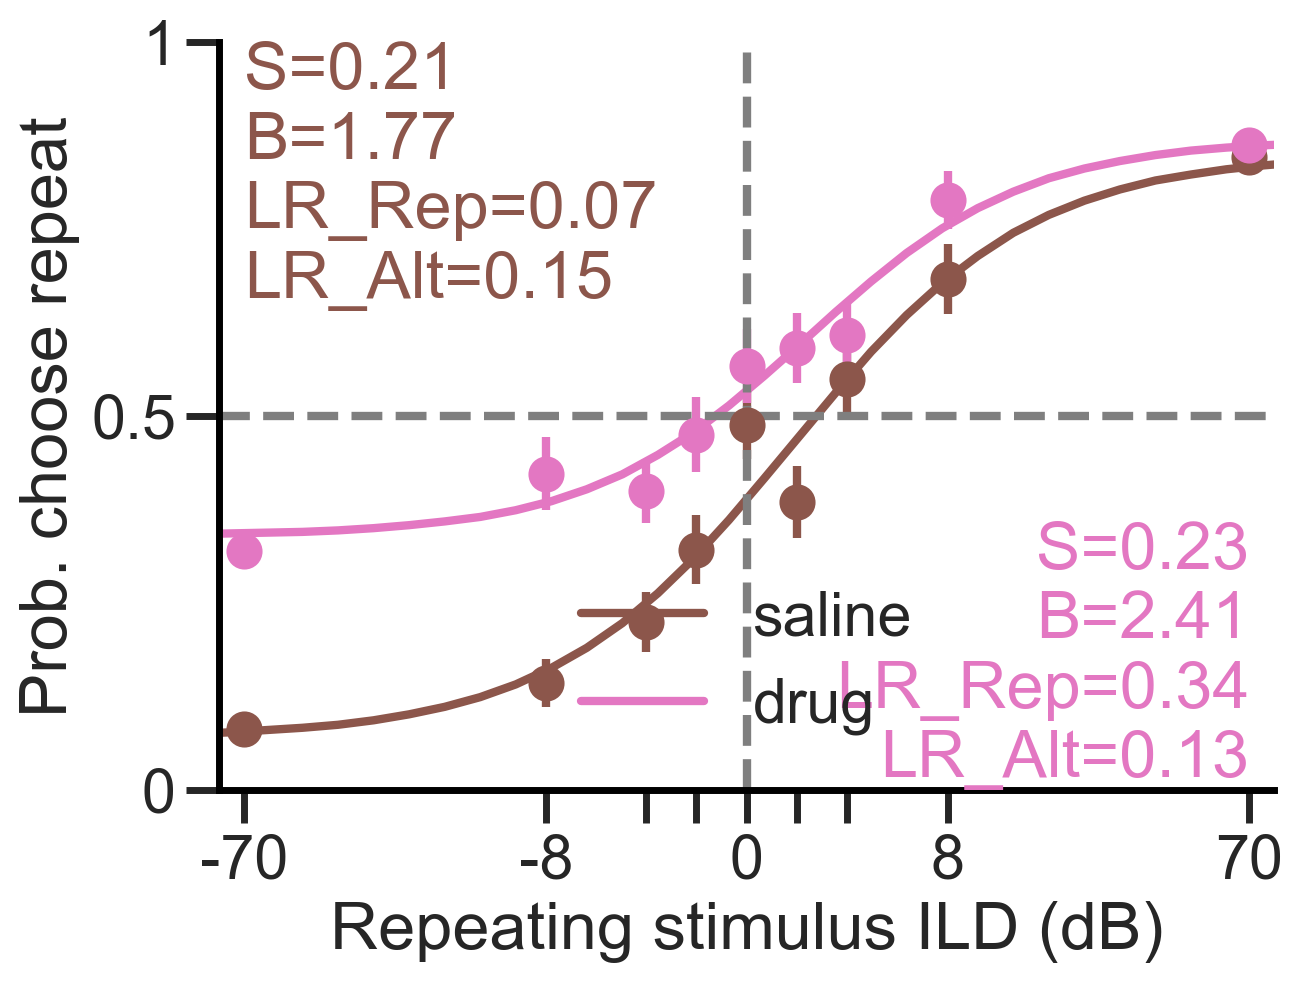

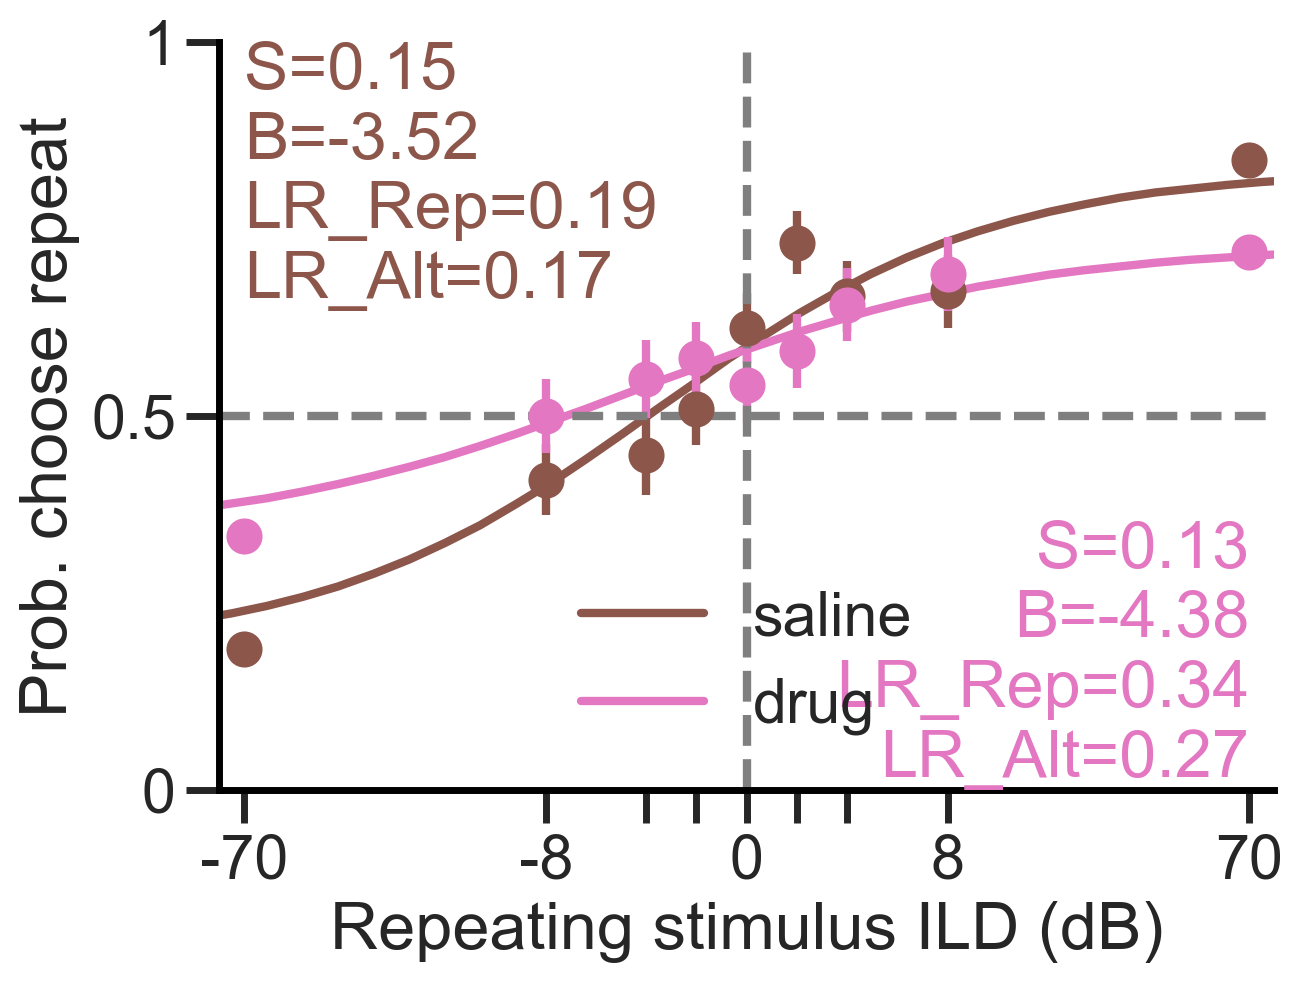

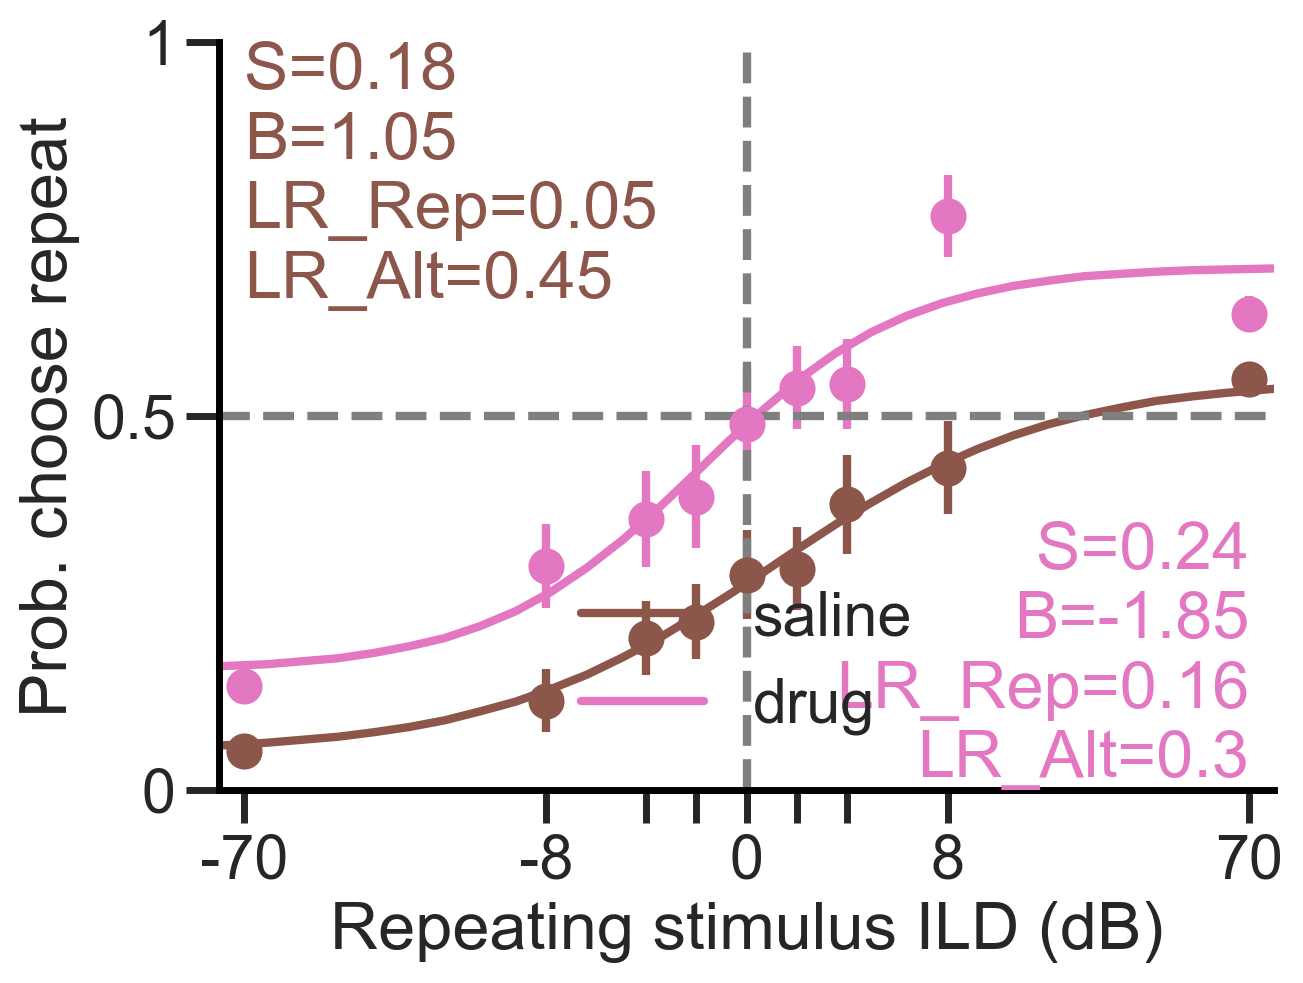

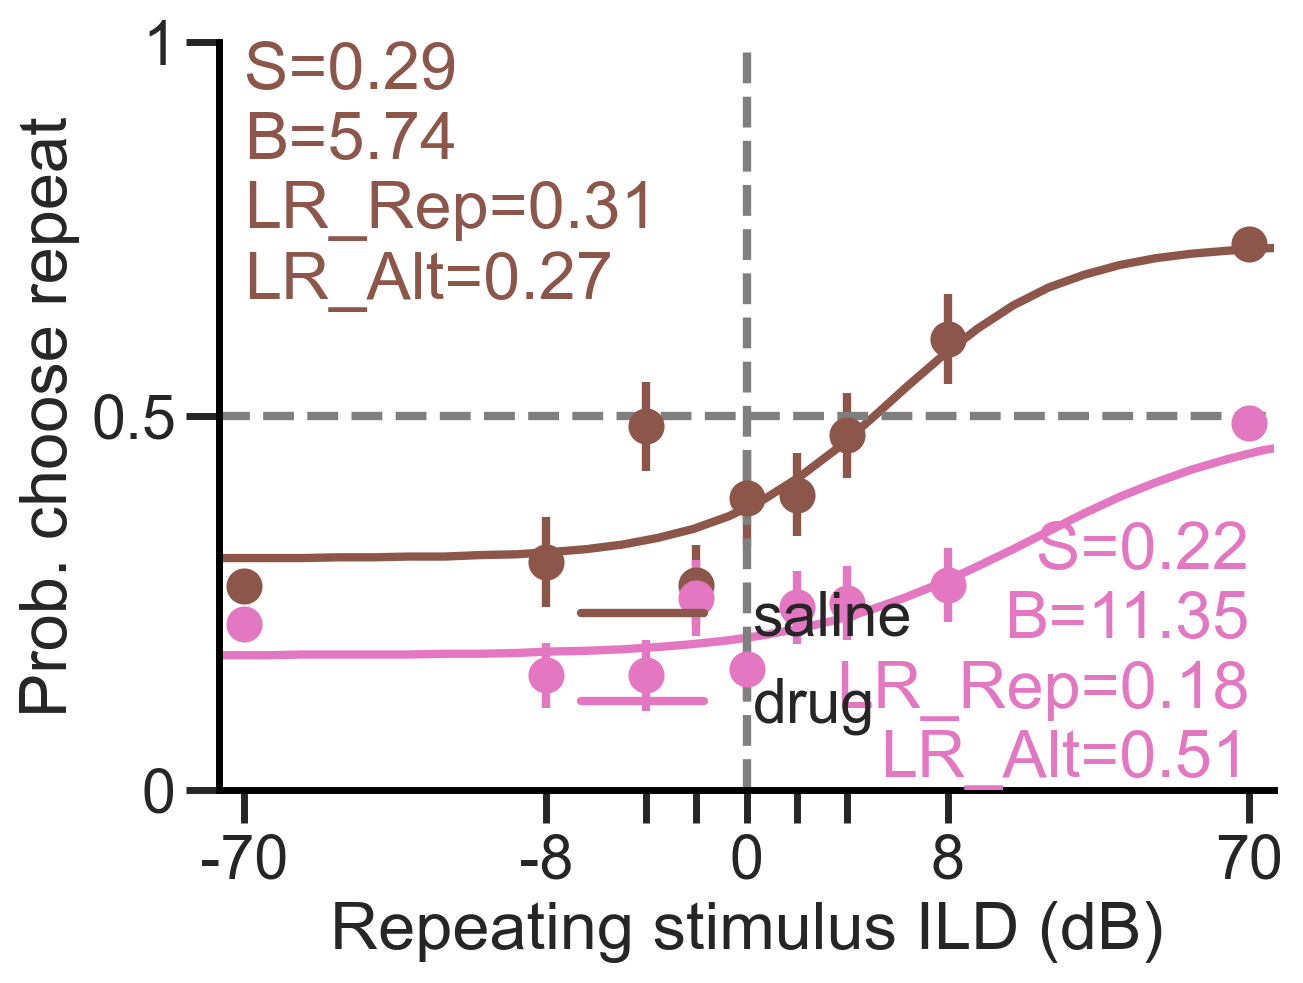

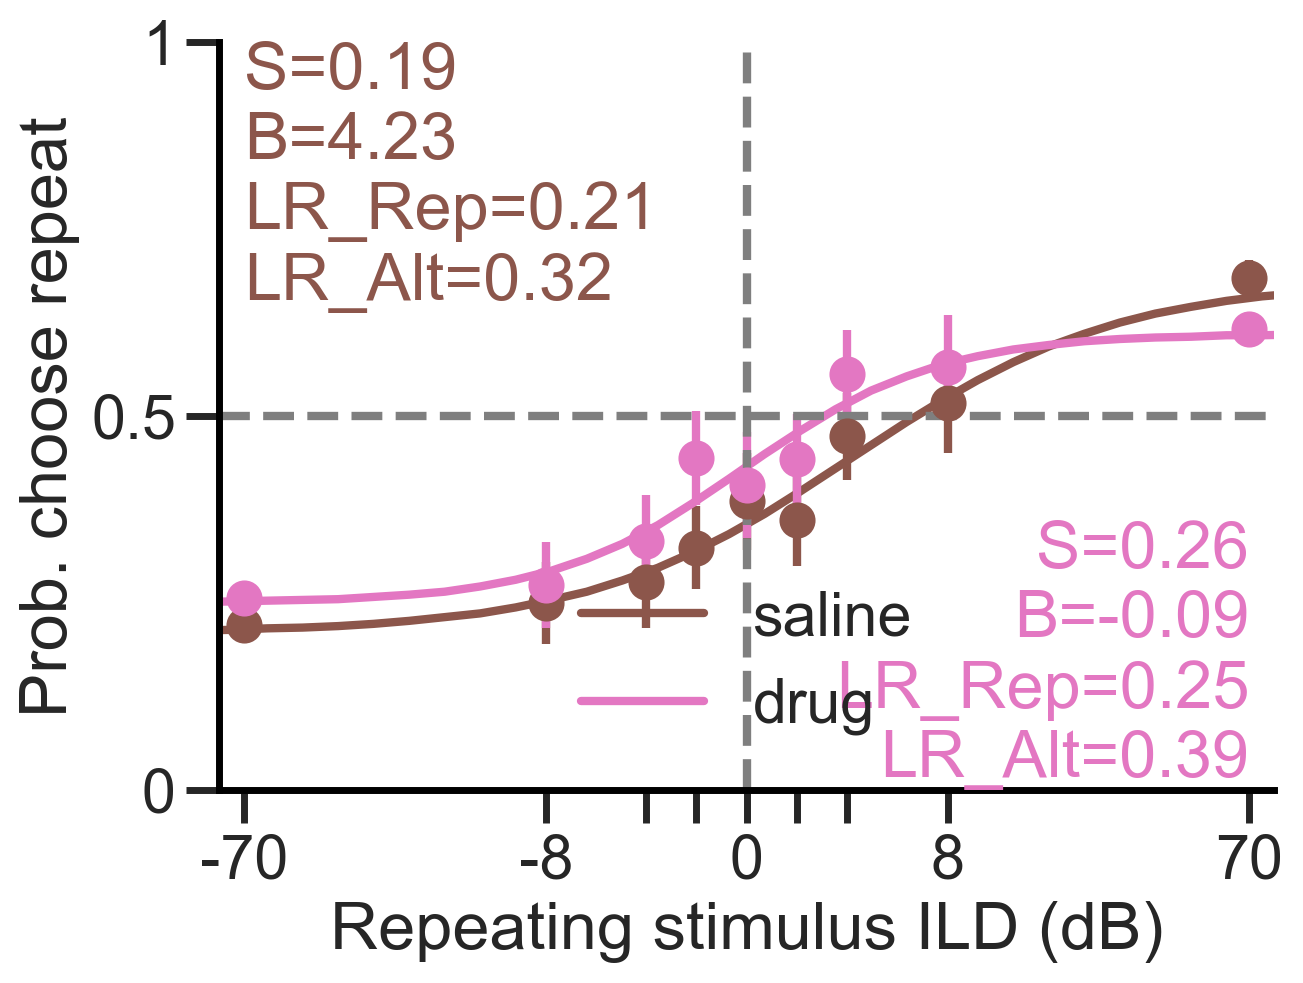

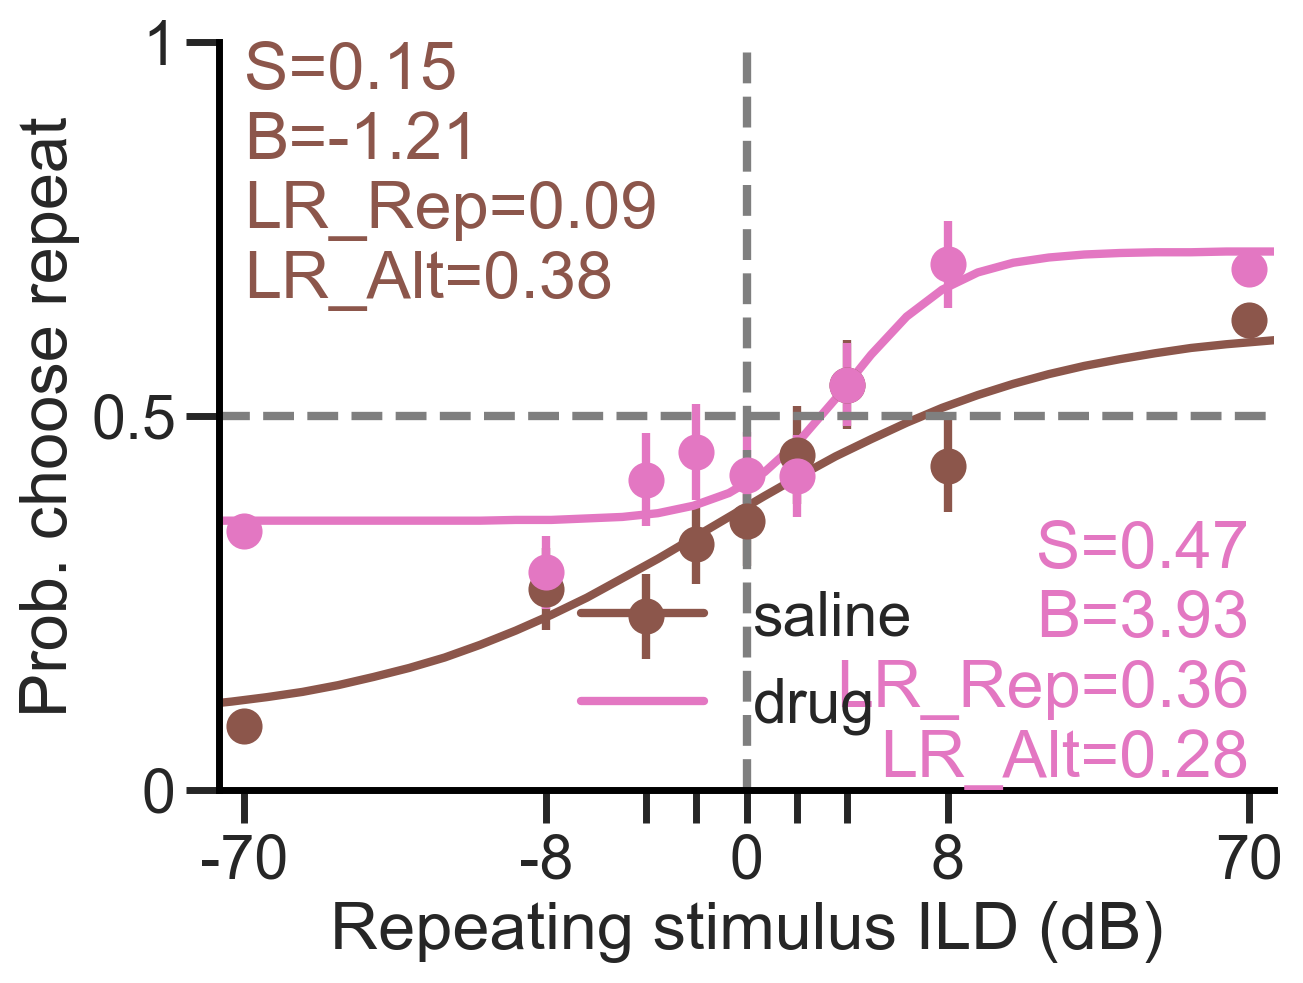

In [14]:
for animal in animals:
    print(f'Animal {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)

#### Mean across animals

plot_mean_pc took 11.25 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:488: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 11.27 seconds to run
plot_mean_pc_drug took 22.54 seconds to run


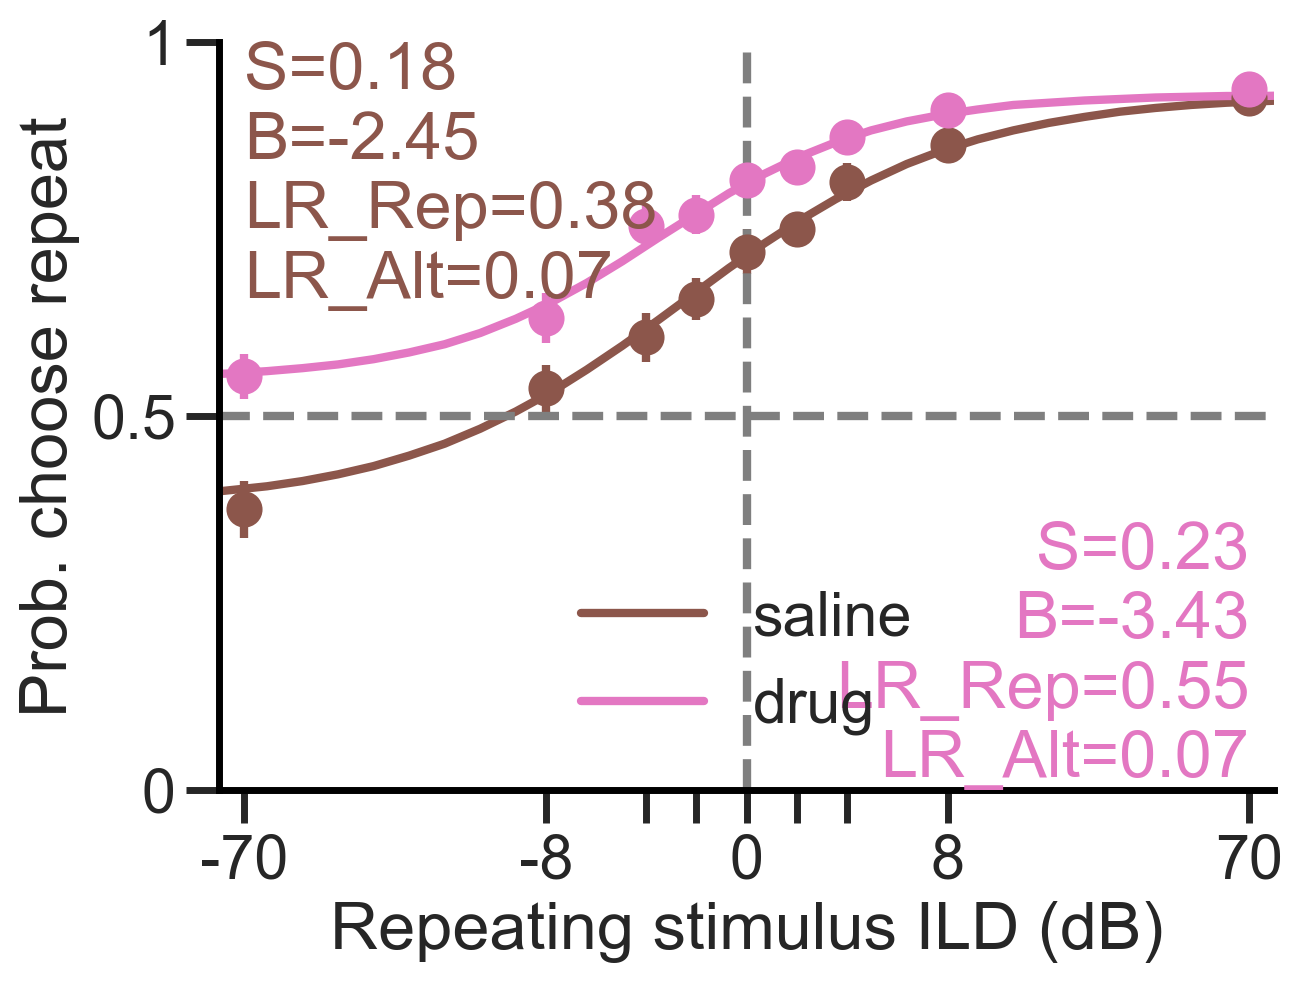

In [15]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

##### Stats

sensitivity: t-statistic = -0.249, p-value = 0.806
bias: t-statistic = 1.293, p-value = 0.214
lr_rep: t-statistic = -3.346, p-value = 0.004
lr_alt: t-statistic = 0.307, p-value = 0.763


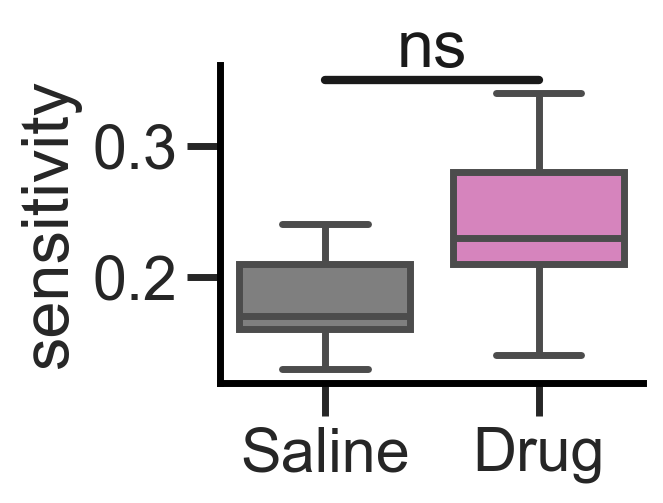

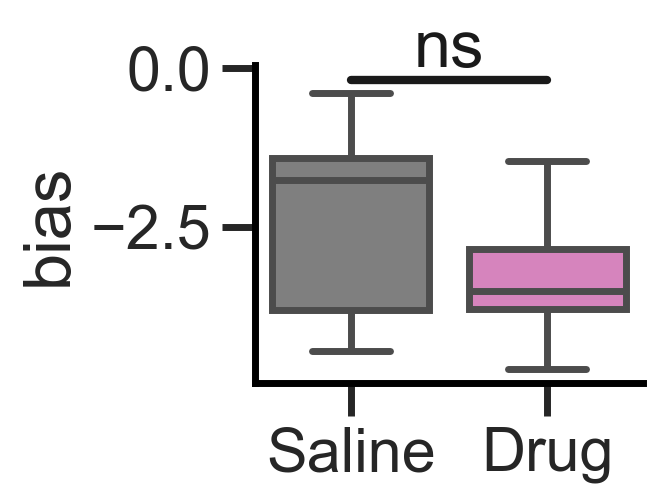

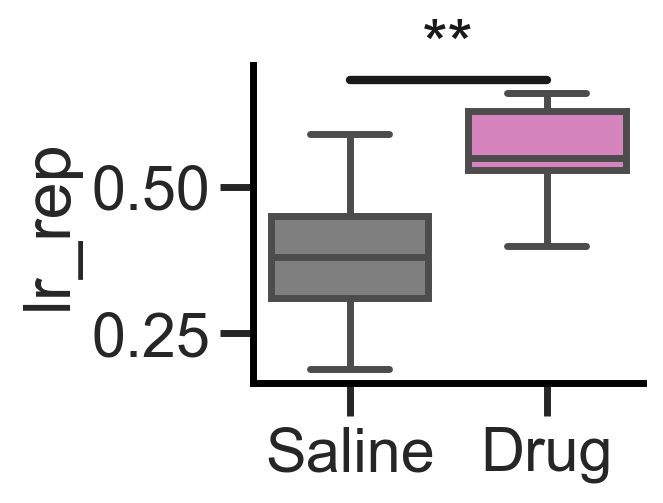

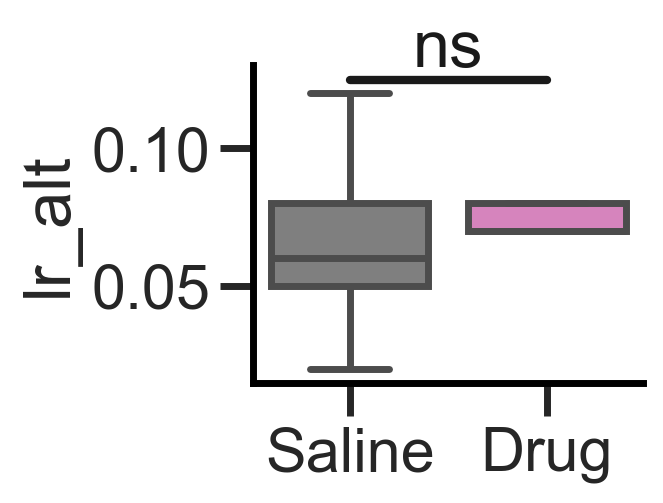

In [16]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_rep')
compare_psych_params(params, 'lr_alt')

## Kernels

### Pshycophisical kernels

#### Mean across animals

In [4]:
# Set parameters
experiment = ['2AFC_6']
animal = None

In [ ]:
# Saline
# plot_pk(experiment=experiment, animal=animal, target_ilds=None, drug=0, residuals=True, zscore=False,
#             control=None, n_mean_frames=None, iterations=10, save=False)

In [ ]:
# Drug
# plot_pk(experiment=experiment, animal=animal, target_ilds=None, drug=1, residuals=True, zscore=False,
#             control=None, n_mean_frames=None, iterations=10, save=False)

In [ ]:
plot_drug_pk(experiment=experiment, animal=None, target_ilds=None, drug=None, residuals=True, zscore=False,
            control=None, n_mean_frames=None, iterations=1000, save=False)

2AFC_6
C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_6
Getting kernel of animal 014 (1/9)


### History kernels

## Serial dependence

In [19]:
# Load data
df = glue_animals(experiment='2AFC_6', update=False, to_csv=False)

loc = df.columns.get_loc('Side') + 1
df.insert(loc, 'PreviousSide', df['Side'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousSide') + 1
df.insert(loc, 'RepSide', (df['Side'] == df['PreviousSide']).astype(int))  # Add repeating stimulus column
loc = df.columns.get_loc('ILD') + 1
df.insert(loc, 'PreviousILD', df['ILD'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousILD') + 1
df.insert(loc, 'DeltaILD', df.PreviousILD - df.ILD)  # Add previous stimulus side column
loc = df.columns.get_loc('DeltaILD') + 1
df.insert(loc, 'absDeltaILD', abs(df.DeltaILD))  # Add previous stimulus side column

# Filter data
df = df[df.Task == 'FD'].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.Hit == 1].reset_index(drop=True)

# Add lick data
df = add_lick_data(df)

loc = df.columns.get_loc('nLicksRight') + 1
df.insert(loc, 'nLicks', np.where(df['Side'] == 0, df['nLicksLeft'], df['nLicksRight']))  # Add number of licks column
df.nLicks = df.nLicks - df.nLicks.mean()  # Substract its mean to nLicks (center at 0)
df.RT = df.RT - df.RT.mean()  # Substract its mean to RT (center at 0)
df.RT2 = df.RT2 - df.RT2.mean()  # Substract its mean to RT2 (center at 0)

df.head()

0.70% of premature lick trials (before response window)
Port1In or Port2In are already lists


,Trial,Side,PreviousSide,RepSide,RepTrial,Reward,Punish,Miss,WrongLick,Hit,...,SessionEnd,LicksLeft,LicksRight,nLicksLeft,nLicksRight,nLicks,ILI_Left,ILI_Right,RT,RT2
0,1,1,1.0,1,NaN,1,0,0,0,1.0,...,12:19:39.607264,[],"[1.8024, 1.9372000000000003, 2.0817]",0,3,-3.639988,NaN,"[0.13480000000000025, 0.14449999999999985]",-0.026308,-0.026308
1,2,1,1.0,1,1.0,1,0,0,0,1.0,...,12:19:39.607264,[],"[1.9699000000000004, 2.1862, 2.2955, 2.4038999...",0,8,1.360012,NaN,"[0.2162999999999995, 0.10930000000000017, 0.10...",0.141192,0.141192
2,3,0,1.0,0,0.0,1,0,0,0,1.0,...,12:19:39.607264,"[1.8217999999999996, 1.9610000000000003, 2.059...","[2.5639000000000003, 2.6929]",8,2,1.360012,"[0.13920000000000066, 0.09879999999999978, 0.1...",[0.12899999999999956],-0.006908,-0.006908
3,4,0,0.0,1,1.0,1,0,0,0,1.0,...,12:19:39.607264,"[1.8061999999999996, 1.9127999999999998, 2.009...","[2.516, 2.6639999999999997]",8,2,1.360012,"[0.10660000000000025, 0.0968, 0.11160000000000...",[0.1479999999999997],-0.022508,-0.022508
4,5,1,0.0,0,0.0,1,0,0,0,1.0,...,12:19:39.607264,[],"[1.7715, 1.9083999999999999, 1.9987, 2.1058999...",0,9,2.360012,NaN,"[0.1368999999999998, 0.09030000000000005, 0.10...",-0.057208,-0.057208


In [128]:
# Check value range of DeltaILD for bining later
np.array(sorted(df.DeltaILD.unique()))

array([-140.,  -78.,  -74.,  -72.,  -70.,  -68.,  -66.,  -62.,  -16.,
        -12.,  -10.,   -8.,   -6.,   -4.,   -2.,    0.,    2.,    4.,
          6.,    8.,   10.,   12.,   16.,   62.,   66.,   68.,   70.,
         72.,   74.,   78.,  140.])

In [28]:
def plot_binned_deltaILD(var='RT', absolute=False):
    """
    Plot binned deltaILD distribution.
    :param var: variable to plot
    :param abs: if True, plot absolute values of deltaILD
    :return:
    """

    # Set bin edges
    if absolute:
        bins = [0, 5, 10, 20, 70, 80, 140]
        col_name = 'absDeltaILD'
        xlabel = 'abs(ΔILD)'
    else:
        bins = [-140, -80, -70, -20, -10, -5 , 5, 10, 20, 70, 80, 140]
        xlabel = 'ΔILD'
        col_name = 'DeltaILD'

    # Create bin labels ( as the bin spacing is not continuous)
    labels = [f"{bins[i]}:{bins[i+1]}" for i in range(len(bins)-1)]

    # Bin the data
    df['ILDbin'] = pd.cut(df[col_name], bins=bins, labels=labels, include_lowest=True)

    # Group and compute means
    mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()

    # Plot
    plt.figure(constrained_layout=True)
    plt.bar(mean_licks['ILDbin'], mean_licks[var], color='tab:gray')
    plt.xlabel(xlabel)
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.title(f'{var} by {xlabel}')
    sns.despine()

### Measured as Reaction Times (RTs)

RT: t-statistic = -2.615, p-value = 0.009


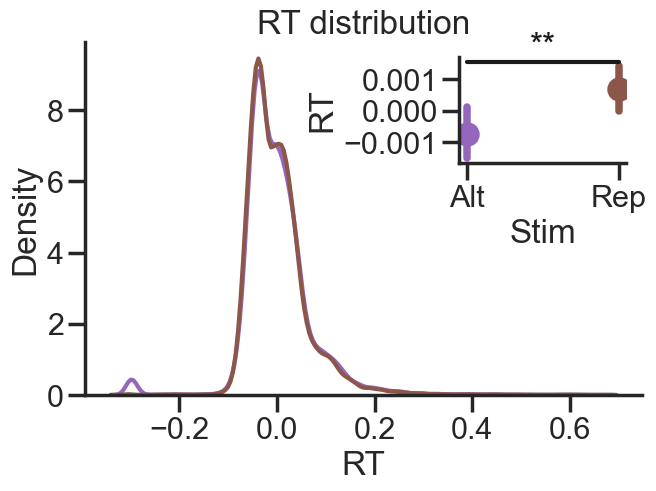

In [13]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].RT, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].RT, label='alt_stim', color='tab:brown')
plt.title('RT distribution')
# plt.legend(frameon=False)
sns.despine()

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='RT', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')

# Run t-test
var_name = 'RT'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17912\1135692533.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()


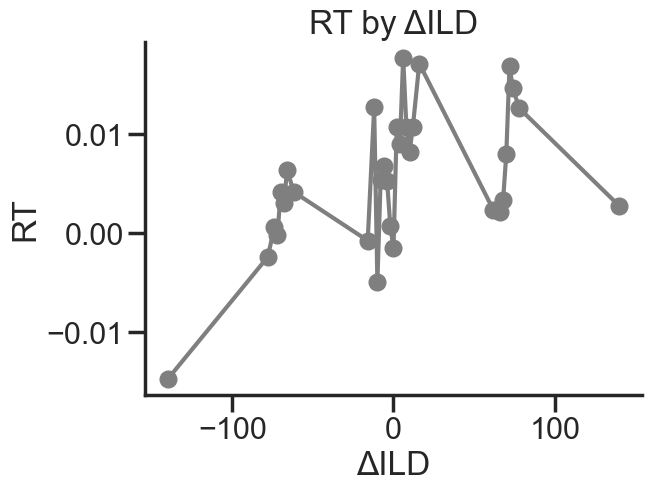

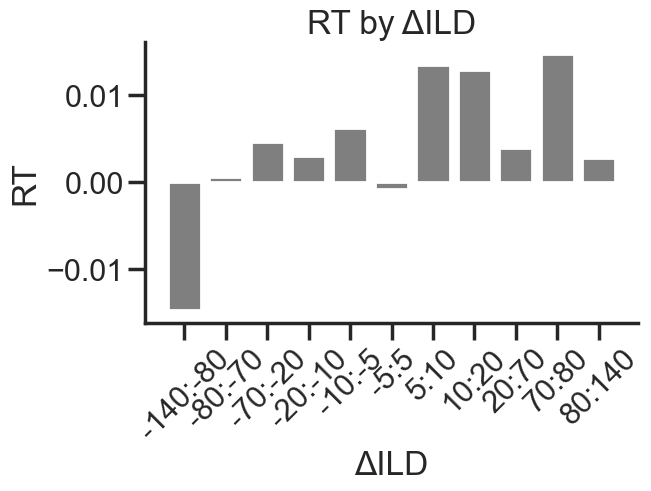

In [29]:
# Plot the RT by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('RT')
plt.title('RT by ΔILD')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=False)

##### Absolute ΔILD

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17912\1135692533.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()


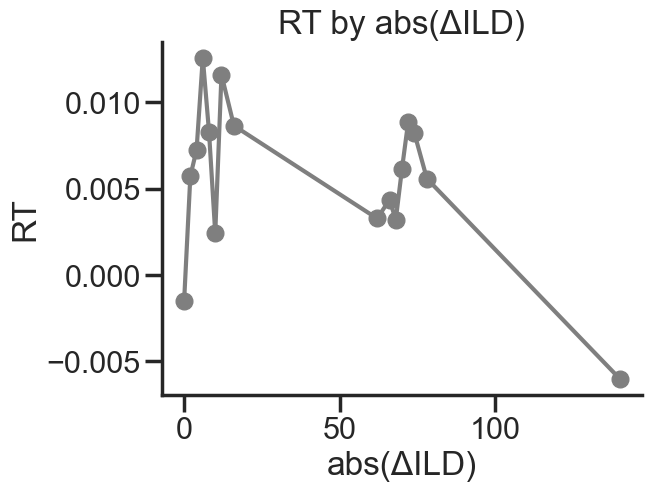

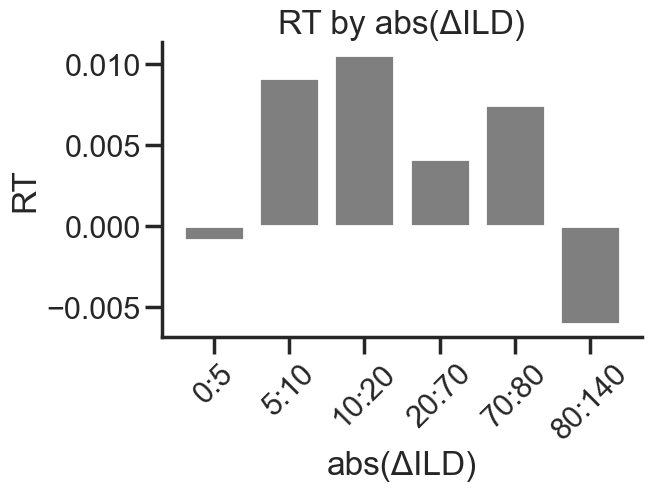

In [30]:
# Plot the RT by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('RT')
plt.title('RT by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=True)

### Measured as N licks

nLicks: t-statistic = -2.847, p-value = 0.004


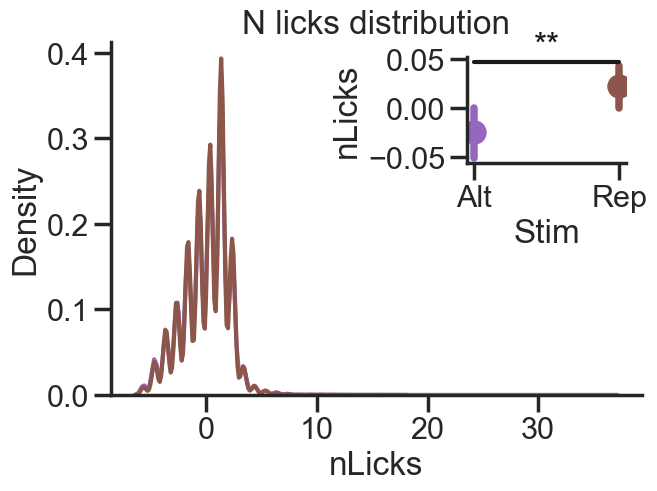

In [23]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].nLicks, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].nLicks, label='alt_stim', color='tab:brown')
plt.title('N licks distribution')
# plt.legend(frameon=False)

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='nLicks', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')
sns.despine()

# Run t-test
var_name = 'nLicks'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17912\1135692533.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()


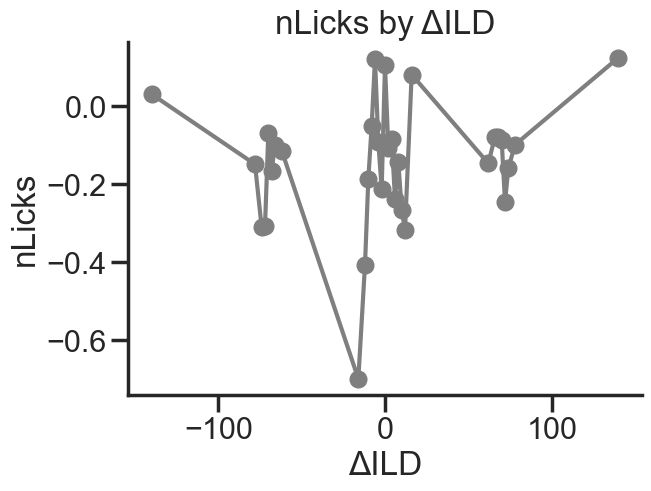

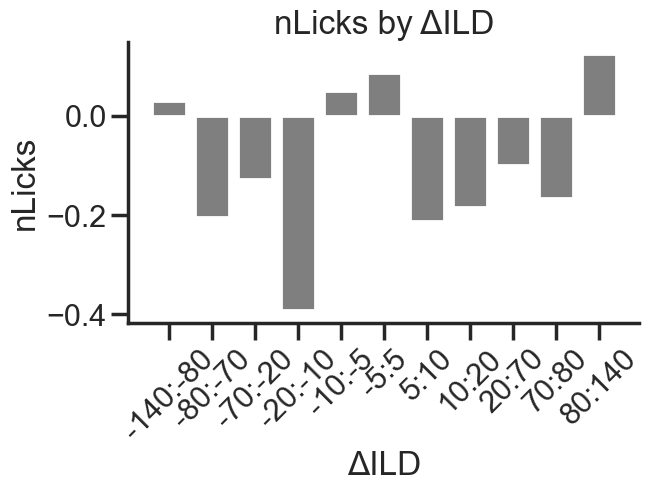

In [31]:
# Plot the number of licks by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('nLicks')
plt.title('nLicks by ΔILD')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=False)

##### Absolute ΔILD

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17912\1135692533.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()


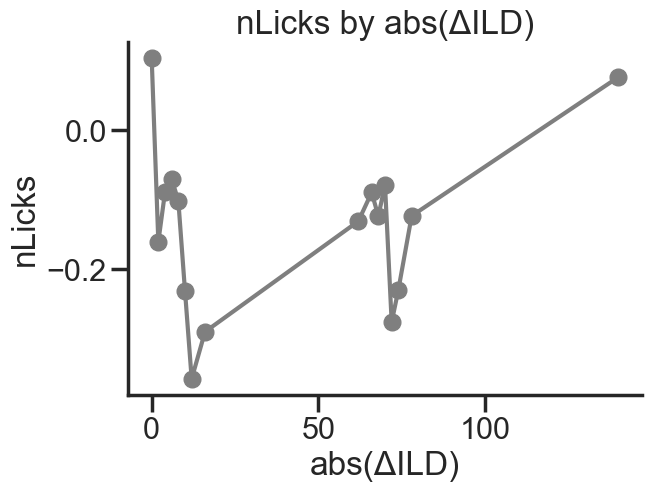

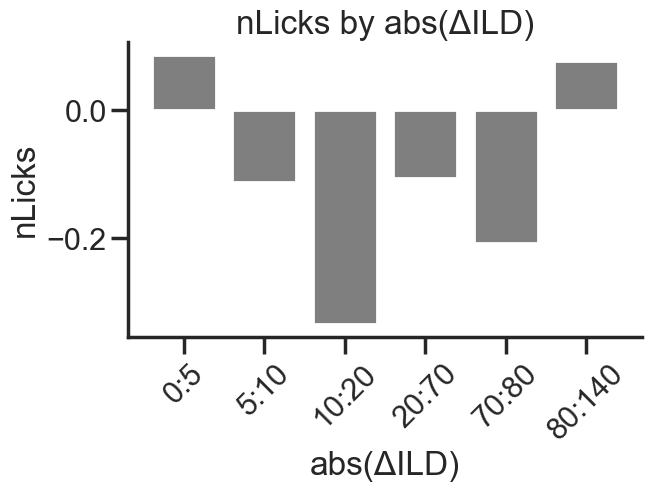

In [32]:
# Plot the number of licks by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('nLicks')
plt.title('nLicks by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=True)